# 🚀 DAQathon Session 1 Advanced Notebook: Tuning, Features, and Better Targets

This notebook picks up where the teaching notebook leaves off.

The focus here is not just to tune models for a higher score. It is to learn how to think about:

- better feature preparation,
- better target design,
- better model-family choices,
- and better sequence representations for neural networks.


## 🧭 How To Use This Advanced Notebook

This notebook is meant to feel like a first clean pass through the workflow:

- understand the dataset and QC flags,
- build one reasonable tabular baseline with a Random Forest,
- build one reasonable sequential baseline with a CNN,
- then ask what we might improve next.

A few suggestions for live teaching:

- read the markdown cells first, then run the code cells underneath them,
- use `DATA_FRACTION` in the config cell to switch between a quick demo and a longer run,
- treat the default model settings as **baseline choices**, not as final answers.

This notebook includes additional hyperparameter search cells, so it is heavier than the teaching notebook.

Optional background reading:

- [Random Forests in scikit-learn](https://scikit-learn.org/stable/modules/ensemble.html#forest)
- [k-means clustering in scikit-learn](https://scikit-learn.org/stable/modules/clustering.html#k-means)
- [Neural networks in PyTorch](https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial)
- [ONC Quality Flags reference](https://wiki.oceannetworks.ca/display/DP/Quality+Flags)


## ⚙️ Configuration

Change values in the next cell if you want to trade speed for fidelity, switch between multiclass and binary classification, or enable the GPU CNN appendix.

On FIR, if `$SLURM_TMPDIR` is available, this notebook first stages the shared raw CSV directory and the prepared parquet cache into node-local job storage. It writes all generated outputs into a runtime directory chosen in this order:

1. `$SLURM_TMPDIR`
2. `$SCRATCH`
3. repo-local `tmp/session1_outputs`


In [ ]:
import os
from pathlib import Path

def first_existing_path(candidates: list[Path]) -> Path | None:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

def first_existing_csv_dir(candidates: list[Path]) -> Path | None:
    for candidate in candidates:
        if candidate.exists() and candidate.is_dir() and any(candidate.glob("*.csv")):
            return candidate
    return None

# Find the repo root for the cloned participant repo.
NOTEBOOK_ROOT = Path.cwd()
for candidate_root in [NOTEBOOK_ROOT, *NOTEBOOK_ROOT.parents]:
    if (candidate_root / "notebooks").exists() and (candidate_root / "scripts").exists():
        NOTEBOOK_ROOT = candidate_root
        break

# Detect the shared FIR project space that holds the long-lived data,
# shared environment, and kernel.
shared_root_candidates = [
    Path("/project/def-kmoran/shared/daqathon"),
    Path("/project/6062898/shared/daqathon"),
    Path.home() / "projects" / "def-kmoran" / "shared" / "daqathon",
]
SHARED_DAQATHON_ROOT = first_existing_path(shared_root_candidates)

LOCAL_RAW_DATA_DIR = NOTEBOOK_ROOT / "data" / "raw" / "SoGEast_CTD_202503_202603"
LOCAL_CACHE_DIR = NOTEBOOK_ROOT / "data" / "cache" / "session1"
SHARED_RAW_DATA_DIR = (
    first_existing_csv_dir(
        [
            SHARED_DAQATHON_ROOT / "data" / "raw" / "SoGEast_CTD_202503_202603",
            SHARED_DAQATHON_ROOT / "data" / "raw",
        ]
    )
    if SHARED_DAQATHON_ROOT
    else None
)
SHARED_CACHE_DIR = (
    first_existing_path([SHARED_DAQATHON_ROOT / "data" / "cache" / "session1"])
    if SHARED_DAQATHON_ROOT
    else None
)

default_raw_candidates = [
    SHARED_RAW_DATA_DIR,
    LOCAL_RAW_DATA_DIR,
    NOTEBOOK_ROOT / "data" / "raw",
]
default_cache_candidates = [
    LOCAL_CACHE_DIR,
    SHARED_CACHE_DIR,
]

DEFAULT_RAW_DATA_DIR = first_existing_csv_dir([candidate for candidate in default_raw_candidates if candidate is not None]) or first_existing_path([candidate for candidate in default_raw_candidates if candidate is not None])
DEFAULT_READ_CACHE_DIR = first_existing_path([candidate for candidate in default_cache_candidates if candidate is not None])

READ_RAW_DATA_DIR = os.environ.get(
    "DAQATHON_RAW_DATA_DIR",
    str(DEFAULT_RAW_DATA_DIR) if DEFAULT_RAW_DATA_DIR is not None else str(LOCAL_RAW_DATA_DIR),
)
READ_CACHE_DIR = os.environ.get(
    "DAQATHON_CACHE_DIR",
    str(DEFAULT_READ_CACHE_DIR) if DEFAULT_READ_CACHE_DIR is not None else str(LOCAL_CACHE_DIR),
)

SLURM_TMPDIR = os.environ.get("SLURM_TMPDIR")
SCRATCH = os.environ.get("SCRATCH")
RUNTIME_OUTPUT_ROOT = (
    Path(SLURM_TMPDIR) / "daqathon" / "session1_outputs"
    if SLURM_TMPDIR
    else (Path(SCRATCH) / "daqathon" / "session1_outputs" if SCRATCH else NOTEBOOK_ROOT / "tmp" / "session1_outputs")
)
RUNTIME_RAW_DATA_DIR = RUNTIME_OUTPUT_ROOT / "data" / "raw" / Path(READ_RAW_DATA_DIR).name
RUNTIME_CACHE_DIR = RUNTIME_OUTPUT_ROOT / "cache" / "session1"
ARTIFACT_DIR = RUNTIME_OUTPUT_ROOT / "artifacts"
MODEL_OUTPUT_DIR = RUNTIME_OUTPUT_ROOT / "models"
PLOT_OUTPUT_DIR = RUNTIME_OUTPUT_ROOT / "plots"
REPORT_OUTPUT_DIR = RUNTIME_OUTPUT_ROOT / "reports"

for output_dir in [RUNTIME_OUTPUT_ROOT, ARTIFACT_DIR, MODEL_OUTPUT_DIR, PLOT_OUTPUT_DIR, REPORT_OUTPUT_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

USE_RUNTIME_RAW_DATA_FOR_READS = bool(SLURM_TMPDIR)
USE_RUNTIME_CACHE_FOR_READS = bool(SLURM_TMPDIR)
RAW_DATA_DIR = str(RUNTIME_RAW_DATA_DIR if USE_RUNTIME_RAW_DATA_FOR_READS else Path(READ_RAW_DATA_DIR))
CACHE_DIR = str(RUNTIME_CACHE_DIR if USE_RUNTIME_CACHE_FOR_READS else Path(READ_CACHE_DIR))

TARGET_FLAG = os.environ.get("DAQATHON_TARGET_FLAG", "Conductivity QC Flag")
TASK_MODE = os.environ.get("DAQATHON_TASK_MODE", "multiclass")

# Keep the feature list in one place so later cells reuse the same columns.
MEASUREMENT_COLUMNS = [
    "Conductivity (S/m)",
    "Density (kg/m3)",
    "Depth (m)",
    "Practical Salinity (psu)",
    "Pressure (decibar)",
    "Sigma-t (kg/m3)",
    "Sigma-theta (0 dbar) (kg/m3)",
    "Sound Speed (m/s)",
    "Temperature (C)",
]

# Read only the parquet columns we actually use in this notebook.
OPTIONAL_QC_COLUMNS = [TARGET_FLAG, "Temperature QC Flag"]
ROW_USE_COLUMNS = list(dict.fromkeys(["Time UTC", "source_file", *OPTIONAL_QC_COLUMNS, *MEASUREMENT_COLUMNS]))
WINDOW_FEATURE_COLUMNS = [
    f"{column}_{stat}"
    for column in MEASUREMENT_COLUMNS
    for stat in ("mean", "std")
]
WINDOW_USE_COLUMNS = [
    "window_start",
    "window_end",
    "source_file",
    "issue_rate",
    *WINDOW_FEATURE_COLUMNS,
]

# Cached parquet locations.
ROW_CACHE_DIR = os.path.join(CACHE_DIR, "ctd_session1_row_level")
WINDOW_CACHE_PATH = os.path.join(CACHE_DIR, "ctd_session1_windowed_features.parquet")
METADATA_PATH = os.path.join(CACHE_DIR, "ctd_session1_metadata.json")

# One easy workshop knob: set this to something like 0.1 for a quick run or 1.0 for the largest local run.
DATA_FRACTION = float(os.environ.get("DAQATHON_DATA_FRACTION", "1.0"))
if not 0 < DATA_FRACTION <= 1:
    raise ValueError("DATA_FRACTION must be in the interval (0, 1].")

# These base values are used later in small local config cells.
BASE_ROWS_PER_FILE = 45000
BASE_ISSUE_ROWS_PER_FILE = 12000
BASE_MODEL_ROW_LIMIT = 1_000_000
BASE_WINDOW_POINT_LIMIT = 1.0
BASE_FLAG_EXAMPLE_POINTS_PER_PANEL = 300

# Global row/window selection policy.
PART_SELECTION_MODE = "spread"
ROW_FILE_LIMIT = None

# Time-based split fractions.
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15

# Toggle the GPU appendix.
RUN_CNN_APPENDIX = True
SEED = 21
RUN_HYPERPARAMETER_SEARCH = True

RF_MODEL_PATH = MODEL_OUTPUT_DIR / "best_random_forest.pkl"
CNN_MODEL_PATH = MODEL_OUTPUT_DIR / "best_cnn_checkpoint.pt"
TRANSFORMER_MODEL_PATH = MODEL_OUTPUT_DIR / "best_transformer_checkpoint.pt"

print(
    {
        "TASK_MODE": TASK_MODE,
        "TARGET_FLAG": TARGET_FLAG,
        "DATA_FRACTION": DATA_FRACTION,
        "RUN_CNN_APPENDIX": RUN_CNN_APPENDIX,
        "SHARED_DAQATHON_ROOT": str(SHARED_DAQATHON_ROOT) if SHARED_DAQATHON_ROOT else None,
        "READ_RAW_DATA_DIR": READ_RAW_DATA_DIR,
        "READ_CACHE_DIR": READ_CACHE_DIR,
        "USE_RUNTIME_RAW_DATA_FOR_READS": USE_RUNTIME_RAW_DATA_FOR_READS,
        "USE_RUNTIME_CACHE_FOR_READS": USE_RUNTIME_CACHE_FOR_READS,
        "RUNTIME_OUTPUT_ROOT": str(RUNTIME_OUTPUT_ROOT),
        "RUNTIME_RAW_DATA_DIR": str(RUNTIME_RAW_DATA_DIR),
        "ROW_CACHE_DIR": ROW_CACHE_DIR,
        "WINDOW_CACHE_PATH": WINDOW_CACHE_PATH,
    }
)


In [ ]:
from __future__ import annotations

import copy
import importlib
import json
import pickle
import subprocess
import sys
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT))

import scripts.prepare_ctd_session1_data as prepare_ctd_session1_data
import scripts.session1_modeling as session1_modeling

importlib.invalidate_caches()
prepare_ctd_session1_data = importlib.reload(prepare_ctd_session1_data)
session1_modeling = importlib.reload(session1_modeling)

add_temporal_context_features = session1_modeling.add_temporal_context_features
apply_target_strategy = session1_modeling.apply_target_strategy
build_labeled_intervals = session1_modeling.build_labeled_intervals
build_model_frame = session1_modeling.build_model_frame
build_sequence_label_interval_data = session1_modeling.build_sequence_label_interval_data
build_window_classification_interval_data = session1_modeling.build_window_classification_interval_data
compute_interval_classification_metrics = session1_modeling.compute_interval_classification_metrics
DEFAULT_FLAG_PALETTE = session1_modeling.DEFAULT_FLAG_PALETTE
evaluate_classifier = session1_modeling.evaluate_classifier
fit_extra_trees = session1_modeling.fit_extra_trees
fit_random_forest = session1_modeling.fit_random_forest
infer_interval_origin = session1_modeling.infer_interval_origin
load_rows_for_time_range = session1_modeling.load_rows_for_time_range
merge_adjacent_intervals = session1_modeling.merge_adjacent_intervals
plot_cluster_window_examples = session1_modeling.plot_cluster_window_examples
plot_flag_examples = session1_modeling.plot_flag_examples
plot_time_series_with_bands = session1_modeling.plot_time_series_with_bands
predict_cnn_window_model = session1_modeling.predict_cnn_window_model
predict_sequence_label_cnn = session1_modeling.predict_sequence_label_cnn
predict_transformer_window_model = session1_modeling.predict_transformer_window_model
resolve_runtime_output_root = session1_modeling.resolve_runtime_output_root
select_time_range = session1_modeling.select_time_range
run_cnn_search = session1_modeling.run_cnn_search
run_rf_search = session1_modeling.run_rf_search
stage_directory_into_runtime = session1_modeling.stage_directory_into_runtime
stage_cache_into_runtime = session1_modeling.stage_cache_into_runtime

KEEP_COLUMNS = prepare_ctd_session1_data.KEEP_COLUMNS
locate_header = prepare_ctd_session1_data.locate_header
read_ctd_csv = prepare_ctd_session1_data.read_ctd_csv

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
np.random.seed(SEED)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# Helper: take an evenly spaced subset without scrambling time order.
def evenly_spaced_take(frame: pd.DataFrame, limit: int | None) -> pd.DataFrame:
    if limit is None or len(frame) <= limit:
        return frame.reset_index(drop=True)
    indices = np.linspace(0, len(frame) - 1, num=limit, dtype=int)
    return frame.iloc[indices].reset_index(drop=True)


# Helper: choose parquet parts spread across the whole year instead of just the first few files.
def select_part_paths(part_paths: list[Path], limit: int | None, mode: str) -> list[Path]:
    if limit is None or limit >= len(part_paths):
        return part_paths
    if mode == "first":
        return part_paths[:limit]
    if mode == "spread":
        indices = np.linspace(0, len(part_paths) - 1, num=limit, dtype=int)
        selected = []
        seen = set()
        for index in indices:
            candidate = part_paths[int(index)]
            if candidate not in seen:
                selected.append(candidate)
                seen.add(candidate)
        return selected
    raise ValueError(f"Unsupported PART_SELECTION_MODE: {mode}")


# Helper: sample each parquet part and deliberately keep extra rows where the QC flag is not 1.
def load_row_level_sample(
    part_paths: list[Path],
    rows_per_file: int | None,
    issue_rows_per_file: int,
    target_flag: str,
    columns: list[str] | None = None,
) -> pd.DataFrame:
    row_frames = []
    for path in part_paths:
        frame = pd.read_parquet(path, columns=columns).sort_values("Time UTC").reset_index(drop=True)
        frame["Time UTC"] = pd.to_datetime(frame["Time UTC"], utc=True)

        if rows_per_file is None:
            sampled_frame = frame
        else:
            base_limit = max(rows_per_file - issue_rows_per_file, 0)
            sampled_frame = evenly_spaced_take(frame, base_limit)

            if issue_rows_per_file > 0 and target_flag in frame.columns:
                issue_frame = frame[frame[target_flag].fillna(1).astype(int) != 1].reset_index(drop=True)
                issue_sample = evenly_spaced_take(issue_frame, issue_rows_per_file)
                sampled_frame = pd.concat([sampled_frame, issue_sample], ignore_index=True)
                sampled_frame = (
                    sampled_frame.drop_duplicates(subset=["Time UTC"])
                    .sort_values("Time UTC")
                    .reset_index(drop=True)
                )
                sampled_frame = evenly_spaced_take(sampled_frame, rows_per_file)

        row_frames.append(sampled_frame)

    return pd.concat(row_frames, ignore_index=True).sort_values("Time UTC").reset_index(drop=True)


# Helper: contiguous splits mimic a real forecasting-style workflow better than random shuffling.
def contiguous_split(
    frame: pd.DataFrame,
    train_fraction: float,
    validation_fraction: float,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_end = int(len(frame) * train_fraction)
    valid_end = int(len(frame) * (train_fraction + validation_fraction))
    train_frame = frame.iloc[:train_end].copy()
    valid_frame = frame.iloc[train_end:valid_end].copy()
    test_frame = frame.iloc[valid_end:].copy()
    return train_frame, valid_frame, test_frame


# Helper: reduce row-level labels to one window-level label for the CNN.
def reduce_window_target(values: np.ndarray, mode: str, severity_order: tuple[int, ...] = (1, 3, 4, 9)) -> int:
    severity_rank = {label: index for index, label in enumerate(severity_order)}
    labels = [int(value) for value in values if pd.notna(value)]
    if not labels:
        return severity_order[0]
    if mode == "worst":
        return max(labels, key=lambda label: severity_rank.get(label, -1))
    counts = pd.Series(labels).value_counts()
    tied_labels = counts[counts == counts.max()].index.tolist()
    return max(tied_labels, key=lambda label: severity_rank.get(int(label), -1))


def report_average(task_mode: str) -> str:
    return "binary" if task_mode == "binary" else "macro"


## 🚀 FIR Input Staging

On FIR, the shared project space is the long-lived home for the workshop data. When `$SLURM_TMPDIR` is available, this notebook first copies the shared raw CSV directory and the prepared parquet cache into node-local storage, because that local job storage is much faster for interactive notebook work.

That means:

- the shared project space stays as the canonical source,
- the notebook reads from a fast local working copy during the run,
- and all generated files stay in your job-local runtime area instead of polluting the shared project tree.

The next code cell shows a progress bar while those copies are happening.


In [ ]:
# On FIR, stage shared inputs into node-local storage before we start reading them.
read_raw_data_dir = Path(READ_RAW_DATA_DIR)
runtime_raw_data_dir = Path(RUNTIME_RAW_DATA_DIR)
read_cache_dir = Path(READ_CACHE_DIR)
runtime_cache_dir = Path(RUNTIME_CACHE_DIR)

raw_stage_result = {"staged": False, "reason": "raw-data staging is disabled because SLURM_TMPDIR is not available"}
cache_stage_result = {"staged": False, "reason": "cache staging is disabled because SLURM_TMPDIR is not available"}
if USE_RUNTIME_RAW_DATA_FOR_READS:
    raw_stage_result = stage_directory_into_runtime(
        source_dir=read_raw_data_dir,
        runtime_dir=runtime_raw_data_dir,
        force=False,
        show_progress=True,
        progress_label="Staging raw CTD CSV files to SLURM_TMPDIR",
    )
if USE_RUNTIME_CACHE_FOR_READS:
    cache_stage_result = stage_cache_into_runtime(
        persistent_cache_dir=read_cache_dir,
        runtime_cache_dir=runtime_cache_dir,
        force=False,
        show_progress=True,
        progress_label="Staging parquet cache to SLURM_TMPDIR",
    )

active_raw_data_dir = runtime_raw_data_dir if runtime_raw_data_dir.exists() and any(runtime_raw_data_dir.glob("*.csv")) else read_raw_data_dir
active_cache_dir = runtime_cache_dir if (runtime_cache_dir / "ctd_session1_metadata.json").exists() else read_cache_dir
RAW_DATA_DIR = str(active_raw_data_dir)
CACHE_DIR = str(active_cache_dir)
ROW_CACHE_DIR = str(active_cache_dir / "ctd_session1_row_level")
WINDOW_CACHE_PATH = str(active_cache_dir / "ctd_session1_windowed_features.parquet")
METADATA_PATH = str(active_cache_dir / "ctd_session1_metadata.json")

print(
    {
        "raw_stage_result": raw_stage_result,
        "cache_stage_result": cache_stage_result,
        "active_raw_data_dir": RAW_DATA_DIR,
        "active_cache_dir": CACHE_DIR,
    }
)


## Part 1 — Orientation and Dataset

Start by understanding what this CTD dataset contains, what the QC flags mean, and what success looks like before we touch any modeling code.


########## About The Dataset

This exercise uses ONC **CTD** data from a Strait of Georgia East instrument. CTD stands for **Conductivity, Temperature, and Depth**, but the export also includes several derived variables such as density, salinity, pressure, sigma-t, sigma-theta, and sound speed.

For this dataset:

- there are **32 CSV files**, spanning approximately **March 2025 to March 2026**,
- each row is one timestamp in **UTC** from the same instrument time series,
- each measured variable has a paired **QC flag** column,
- the raw ONC CSV files include a long metadata header before the actual table begins.

A useful mental model is: each row is one moment in time, and each column is either a measured value, a derived value, or a QC assessment attached to that moment.

Why this dataset is useful for Session 1:

- it is large enough to make caching and careful sampling matter,
- it includes both *good* and *problematic* observations,
- it supports both supervised learning and unsupervised exploration,
- it is a real operational dataset rather than a toy example.


########## What The QC Flags Mean

The ONC header includes this QC flag legend. This is important because the machine-learning target is not a physical measurement like temperature; it is ONC's quality assessment for that timestamp.

- `0`: no QC
- `1`: good
- `2`: probably good, use with caution
- `3`: probably bad
- `4`: bad
- `6`: bad down-sampling
- `7`: averaged value
- `8`: interpolated value
- `9`: missing value (`NaN`)

For `Conductivity QC Flag`, the full cache currently includes `1`, `3`, `4`, and `9`. That is why a multiclass problem is reasonable here.

In plain language for this session:

- `1` is the normal, healthy case,
- `3` and `4` are increasingly concerning quality issues,
- `9` is effectively telling us the value is missing.

If we switch to binary mode later, we collapse `3`, `4`, and `9` into a single `issue = 1` class.


## Part 2 — Data Preparation and Caching

This part explains how we turn raw ONC CSV exports into typed parquet tables that are much easier to load repeatedly during a workshop.


### 🧹 How We Prepare The Data

The raw preparation is handled by `scripts/prepare_ctd_session1_data.py`. We do that once up front because the original CSVs have slow I/O and repeated parsing would make the workshop feel sluggish.

The script does one clean pass over the raw files:

- finds the real ONC table header and skips the metadata block above it,
- keeps `Time UTC`, the CTD measurement columns, and the paired QC flag columns,
- converts timestamps, measurements, and QC flags into typed columns,
- drops rows with unparseable timestamps and sorts by time.

From that cleaned table it writes two reusable caches:

- **row-level parquet**: one row per timestamp, used for supervised learning,
- **window-summary parquet**: one row per fixed time window, used for clustering and sequence work.

Inside the notebook we do **sampling and modeling**, not raw parsing. That keeps the live session fast and makes the workflow easier to explain.


### 📦 Optional Step: Build The Parquet Cache From Raw CSV Files

Raw CSV is still the source of truth, but it is a poor format for repeated ML work. These ONC files include a metadata block before the actual table, need timestamp and numeric parsing, and are slower to reread than a typed columnar format.

So we do one preparation step, save parquet, and reuse that cache for the rest of the notebook.

Any cache that this notebook generates is written into the runtime output area, not back into the shared FIR cache.

The next cells let us either:

- rebuild the cache from raw CSV, or
- inspect the cache that already exists.


In [ ]:
RUN_RAW_PREP = False
FORCE_REBUILD_CACHE = False
PREP_MAX_FILES = None
PREP_SAMPLE_ROWS = None
PREP_WINDOW_SIZE = 256

print(
    {
        "RUN_RAW_PREP": RUN_RAW_PREP,
        "FORCE_REBUILD_CACHE": FORCE_REBUILD_CACHE,
        "PREP_MAX_FILES": PREP_MAX_FILES,
        "PREP_SAMPLE_ROWS": PREP_SAMPLE_ROWS,
        "PREP_WINDOW_SIZE": PREP_WINDOW_SIZE,
    }
)


In [ ]:
raw_data_path = Path(RAW_DATA_DIR)
cache_root_path = Path(RUNTIME_CACHE_DIR)
prep_script_path = NOTEBOOK_ROOT / "scripts" / "prepare_ctd_session1_data.py"
cache_metadata_path = cache_root_path / "ctd_session1_metadata.json"

prep_command = [
    sys.executable,
    str(prep_script_path),
    "--data-root",
    str(raw_data_path),
    "--cache-root",
    str(cache_root_path),
    "--target-flag",
    TARGET_FLAG,
    "--window-size",
    str(PREP_WINDOW_SIZE),
]
if PREP_MAX_FILES is not None:
    prep_command.extend(["--max-files", str(PREP_MAX_FILES)])
if PREP_SAMPLE_ROWS is not None:
    prep_command.extend(["--sample-rows", str(PREP_SAMPLE_ROWS)])

should_run_prep = RUN_RAW_PREP or FORCE_REBUILD_CACHE or not cache_metadata_path.exists()
print({"should_run_prep": should_run_prep, "cache_exists": cache_metadata_path.exists()})
print("Prep command:")
print(" ".join(prep_command))
print({"prep_output_cache_dir": str(cache_root_path)})

if should_run_prep:
    completed = subprocess.run(prep_command, cwd=NOTEBOOK_ROOT, check=True, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
else:
    print("Skipping cache rebuild because a prepared runtime cache already exists. Set RUN_RAW_PREP = True to rebuild it.")


### ⚡ Why The Parquet Cache Helps

The point of the cache is not just convenience. It changes the workflow:

- raw CSV is for ingestion and provenance,
- parquet is for repeated analysis and model training.

In the summary below:

- `parsed columns` means every column recovered from a representative raw ONC table,
- `row columns used in notebook` means the smaller row-level subset we load for supervised modeling,
- `window columns used in notebook` means the summary-feature subset we load from the window cache for clustering.

The **row parquet cache** keeps one row per timestamp.

The **window-summary parquet** keeps one row per fixed time window, with summary features such as means, standard deviations, and issue rates. That makes it useful when we want to reason about short stretches of time rather than isolated rows.

The next cells make those benefits visible with concrete measurements.


In [ ]:
def directory_size_bytes(path: Path, pattern: str) -> int:
    return sum(file_path.stat().st_size for file_path in path.glob(pattern) if file_path.is_file())

raw_files = sorted(Path(RAW_DATA_DIR).glob("*.csv"))
row_cache_parts = sorted(Path(ROW_CACHE_DIR).glob("*.parquet"))
if not raw_files:
    raise FileNotFoundError(f"No raw CSV files found in {RAW_DATA_DIR}")
if not row_cache_parts:
    raise FileNotFoundError(f"No parquet parts found in {ROW_CACHE_DIR}")
if not cache_metadata_path.exists():
    raise FileNotFoundError(f"No cache metadata found at {cache_metadata_path}")

cache_metadata = json.loads(cache_metadata_path.read_text())
representative_info = cache_metadata["processed_files"][0]
representative_raw_path = Path(RAW_DATA_DIR) / representative_info["source_file"]
representative_parquet_path = Path(ROW_CACHE_DIR) / Path(representative_info["row_level_part"]).name
header_line_number, parsed_columns = locate_header(representative_raw_path)

with representative_raw_path.open("r", encoding="utf-8") as handle:
    raw_header_preview = [next(handle).rstrip("\n") for _ in range(8)]

raw_total_bytes = directory_size_bytes(Path(RAW_DATA_DIR), "*.csv")
parquet_total_bytes = directory_size_bytes(Path(ROW_CACHE_DIR), "*.parquet")
window_cache_bytes = Path(WINDOW_CACHE_PATH).stat().st_size if Path(WINDOW_CACHE_PATH).exists() else 0

cache_comparison = pd.DataFrame(
    [
        {"artifact": "Raw CSV files", "bytes": raw_total_bytes},
        {"artifact": "Row parquet cache", "bytes": parquet_total_bytes},
        {"artifact": "Window parquet cache", "bytes": window_cache_bytes},
    ]
)
cache_comparison["megabytes"] = cache_comparison["bytes"] / (1024 ** 2)
cache_comparison["gigabytes"] = cache_comparison["bytes"] / (1024 ** 3)
display(cache_comparison)

column_sets = pd.DataFrame(
    [
        {
            "column_set": "Parsed columns from raw CSV",
            "count": len(parsed_columns),
            "examples": ", ".join(parsed_columns[:6]) + (" ..." if len(parsed_columns) > 6 else ""),
        },
        {
            "column_set": "Row columns loaded in this notebook",
            "count": len(ROW_USE_COLUMNS),
            "examples": ", ".join(ROW_USE_COLUMNS[:6]) + (" ..." if len(ROW_USE_COLUMNS) > 6 else ""),
        },
        {
            "column_set": "Window columns loaded in this notebook",
            "count": len(WINDOW_USE_COLUMNS),
            "examples": ", ".join(WINDOW_USE_COLUMNS[:6]) + (" ..." if len(WINDOW_USE_COLUMNS) > 6 else ""),
        },
    ]
)
display(column_sets)

print(
    {
        "raw_file_count": len(raw_files),
        "parquet_part_count": len(row_cache_parts),
        "metadata_lines_before_table": header_line_number - 1,
        "parsed_column_count": len(parsed_columns),
        "row_columns_used_in_notebook": len(ROW_USE_COLUMNS),
        "window_columns_used_in_notebook": len(WINDOW_USE_COLUMNS),
        "full_row_count": cache_metadata["row_count"],
        "full_window_count": cache_metadata["window_count"],
    }
)
print("Representative raw CSV preview:")
print("\n".join(raw_header_preview))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(cache_comparison["artifact"], cache_comparison["gigabytes"], color=["#5B7C99", "#2A9D8F", "#E9C46A"])
axes[0].set_ylabel("Size on disk (GB)")
axes[0].set_title("Disk footprint of raw and cached artifacts")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(
    ["Parsed columns", "Row cols used here", "Window cols used here"],
    [len(parsed_columns), len(ROW_USE_COLUMNS), len(WINDOW_USE_COLUMNS)],
    color=["#7A6FF0", "#3A86FF", "#00A896"],
)
axes[1].set_ylabel("Column count")
axes[1].set_title("Parquet lets us load only the columns we need")
plt.tight_layout()
plt.show()


In [ ]:
csv_start = perf_counter()
csv_frame = read_ctd_csv(representative_raw_path, sample_rows=None)
csv_elapsed = perf_counter() - csv_start

parquet_full_start = perf_counter()
parquet_full_frame = pd.read_parquet(representative_parquet_path)
parquet_full_elapsed = perf_counter() - parquet_full_start

parquet_pruned_start = perf_counter()
parquet_pruned_frame = pd.read_parquet(representative_parquet_path, columns=ROW_USE_COLUMNS)
parquet_pruned_elapsed = perf_counter() - parquet_pruned_start

benchmark_summary = pd.DataFrame(
    [
        {
            "read_path": "Raw CSV parse",
            "seconds": csv_elapsed,
            "rows_loaded": len(csv_frame),
            "memory_mb": csv_frame.memory_usage(deep=True).sum() / (1024 ** 2),
        },
        {
            "read_path": "Parquet full load",
            "seconds": parquet_full_elapsed,
            "rows_loaded": len(parquet_full_frame),
            "memory_mb": parquet_full_frame.memory_usage(deep=True).sum() / (1024 ** 2),
        },
        {
            "read_path": "Parquet column-pruned load",
            "seconds": parquet_pruned_elapsed,
            "rows_loaded": len(parquet_pruned_frame),
            "memory_mb": parquet_pruned_frame.memory_usage(deep=True).sum() / (1024 ** 2),
        },
    ]
)
benchmark_summary["rows_per_second"] = benchmark_summary["rows_loaded"] / benchmark_summary["seconds"].clip(lower=1e-9)
display(benchmark_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(benchmark_summary["read_path"], benchmark_summary["seconds"], color=["#E76F51", "#2A9D8F", "#457B9D"])
axes[0].set_ylabel("Elapsed time (s)")
axes[0].set_title("Read time for one full representative file")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(benchmark_summary["read_path"], benchmark_summary["rows_per_second"], color=["#E76F51", "#2A9D8F", "#457B9D"])
axes[1].set_ylabel("Rows per second")
axes[1].set_title("Typed parquet is faster for repeated analysis reads")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

print(
    {
        "csv_seconds": round(csv_elapsed, 4),
        "parquet_full_seconds": round(parquet_full_elapsed, 4),
        "parquet_pruned_seconds": round(parquet_pruned_elapsed, 4),
        "full_file_speedup_ratio": round(csv_elapsed / max(parquet_full_elapsed, 1e-9), 2),
        "column_pruned_speedup_ratio": round(csv_elapsed / max(parquet_pruned_elapsed, 1e-9), 2),
    }
)


## Part 3 — Feature Engineering and Data Loading

Now that the cache is prepared, we can load only the columns we need, inspect time-series examples, and build the row-level features that feed the models.


In [ ]:
# Load the metadata that was written during cache preparation.
persistent_cache_dir = Path(READ_CACHE_DIR)
runtime_cache_dir = Path(RUNTIME_CACHE_DIR)
runtime_metadata_path = runtime_cache_dir / "ctd_session1_metadata.json"

active_cache_dir = runtime_cache_dir if runtime_metadata_path.exists() else persistent_cache_dir
CACHE_DIR = str(active_cache_dir)
ROW_CACHE_DIR = str(active_cache_dir / "ctd_session1_row_level")
WINDOW_CACHE_PATH = str(active_cache_dir / "ctd_session1_windowed_features.parquet")
METADATA_PATH = str(active_cache_dir / "ctd_session1_metadata.json")

row_cache_dir = Path(ROW_CACHE_DIR)
window_cache_path = Path(WINDOW_CACHE_PATH)
metadata_path = Path(METADATA_PATH)

if not metadata_path.exists():
    raise FileNotFoundError(
        f"Missing cache metadata at {metadata_path}. Run scripts/prepare_ctd_session1_data.py first."
    )

metadata = json.loads(metadata_path.read_text())
part_paths = sorted(row_cache_dir.glob("*.parquet"))
if not part_paths:
    raise FileNotFoundError(f"No parquet parts found in {row_cache_dir}")

# Choose parquet parts spread across the full year.
selected_paths = select_part_paths(part_paths, limit=ROW_FILE_LIMIT, mode=PART_SELECTION_MODE)
part_to_source = {
    Path(file_info["row_level_part"]).name: file_info["source_file"]
    for file_info in metadata["processed_files"]
}
source_to_row_part = {
    file_info["source_file"]: file_info["row_level_part"]
    for file_info in metadata["processed_files"]
}
selected_source_files = {part_to_source[path.name] for path in selected_paths}

print(
    {
        "active_cache_dir": str(active_cache_dir),
        "persistent_cache_dir": str(persistent_cache_dir),
        "runtime_output_root": str(RUNTIME_OUTPUT_ROOT),
        "model_output_dir": str(MODEL_OUTPUT_DIR),
    }
)


In [23]:
# Summarize the overall cache before loading row samples.
cache_summary = {
    "full_row_count": metadata["row_count"],
    "full_window_count": metadata["window_count"],
    "processed_file_count": metadata["processed_file_count"],
    "issue_fraction": round(float(metadata["issue_fraction"]), 4),
    "task_mode": TASK_MODE,
}
print(cache_summary)

selected_file_summary = pd.DataFrame(metadata["processed_files"])
selected_file_summary = selected_file_summary[selected_file_summary["source_file"].isin(selected_source_files)].reset_index(drop=True)
selected_file_summary = selected_file_summary[["source_file", "row_count", "time_start", "time_end"]].copy()
selected_file_summary["source_file"] = selected_file_summary["source_file"].str.replace(
    r"_\d{8}T\d{6}Z_\d{8}T\d{6}Z-NaN\.csv$",
    "",
    regex=True,
)
display(selected_file_summary.head(5))


{'full_row_count': 31881527, 'full_window_count': 124561, 'processed_file_count': 32, 'issue_fraction': 0.07, 'task_mode': 'multiclass'}


,source_file,row_count,time_start,time_end
0,StraitofGeorgiaEast_StraitofGeorgiaEastVENUSIn...,1000000,2025-03-23T00:00:00.718000+00:00,2025-04-03T13:46:43.422000+00:00
1,StraitofGeorgiaEast_StraitofGeorgiaEastVENUSIn...,1000000,2025-04-03T13:46:44.397000+00:00,2025-04-15T03:33:22.991000+00:00
2,StraitofGeorgiaEast_StraitofGeorgiaEastVENUSIn...,1000000,2025-04-15T03:33:24.054000+00:00,2025-04-26T17:20:08.125000+00:00
3,StraitofGeorgiaEast_StraitofGeorgiaEastVENUSIn...,1000000,2025-04-26T17:20:09.035000+00:00,2025-05-08T07:06:53.149000+00:00
4,StraitofGeorgiaEast_StraitofGeorgiaEastVENUSIn...,1000000,2025-05-08T07:06:54.161000+00:00,2025-05-19T20:53:38.500000+00:00


### 🚚 Loading More Data Efficiently

In this notebook we want to use **as much useful data as possible** without turning every cell into a slow I/O bottleneck.

The easiest control is `DATA_FRACTION` in the configuration cell:

- set `DATA_FRACTION = 0.1` for a quick live demo,
- set `DATA_FRACTION = 0.25` or `0.5` for a medium run,
- set `DATA_FRACTION = 1.0` to use the largest local profile we prepared for this workshop.

The strategy is different for the two model families:

- **Tree models** such as Random Forest still want one in-memory feature matrix, so we make that matrix more efficient by reading parquet instead of raw CSV, pruning unused columns, and sampling across the full year instead of only the first files.
- **Neural networks** can train in mini-batches, so later we will use a PyTorch `DataLoader` to stream batches to the GPU instead of pushing the whole dataset through the device at once.

For the row-level cache we do three important things:

- choose parquet parts spread across the whole time range,
- read only the columns this notebook actually needs,
- keep extra non-`1` rows so rare QC cases are still visible in the training set.


### 🎚️ Data Loading Controls

These settings control how much of the cached dataset we load for the supervised and unsupervised sections.

Main variables:

- `ROWS_PER_FILE`: how many row-level samples to keep from each parquet part.
- `ISSUE_ROWS_PER_FILE`: extra non-`1` QC rows to keep so rarer flags still appear.
- `MODEL_ROW_LIMIT`: final cap on the tabular training frame used by the Random Forest.

Common alternatives:

- increase these values when you want stronger models and have more time,
- decrease them for a quick live demo,
- set `ROW_FILE_LIMIT` to a small number only if you intentionally want to use fewer source files.


In [ ]:
ROWS_PER_FILE = max(5000, int(BASE_ROWS_PER_FILE * DATA_FRACTION))
ISSUE_ROWS_PER_FILE = max(1000, int(BASE_ISSUE_ROWS_PER_FILE * DATA_FRACTION))
MODEL_ROW_LIMIT = max(100000, int(BASE_MODEL_ROW_LIMIT * DATA_FRACTION))

print(
    {
        "ROWS_PER_FILE": ROWS_PER_FILE,
        "ISSUE_ROWS_PER_FILE": ISSUE_ROWS_PER_FILE,
        "MODEL_ROW_LIMIT": MODEL_ROW_LIMIT,
    }
)


In [ ]:
# Load only the row-level columns we will actually use for plotting and supervised learning.
df = load_row_level_sample(
    selected_paths,
    rows_per_file=ROWS_PER_FILE,
    issue_rows_per_file=ISSUE_ROWS_PER_FILE,
    target_flag=TARGET_FLAG,
    columns=ROW_USE_COLUMNS,
)

# Load the cached window summaries for clustering, again with column pruning.
window_df = pd.read_parquet(window_cache_path, columns=WINDOW_USE_COLUMNS)
window_df["window_start"] = pd.to_datetime(window_df["window_start"], utc=True)
window_df["window_end"] = pd.to_datetime(window_df["window_end"], utc=True)
window_df = (
    window_df[window_df["source_file"].isin(selected_source_files)]
    .sort_values("window_start")
    .reset_index(drop=True)
)
window_limit = None if DATA_FRACTION >= 0.999 else max(2000, int(len(window_df) * DATA_FRACTION))
window_df = evenly_spaced_take(window_df, window_limit)

print(
    {
        "selected_parts": len(selected_paths),
        "loaded_rows": len(df),
        "loaded_windows": len(window_df),
        "data_fraction": DATA_FRACTION,
        "row_columns_loaded": len(ROW_USE_COLUMNS),
        "window_columns_loaded": len(WINDOW_USE_COLUMNS),
        "rows_per_file": ROWS_PER_FILE,
        "issue_rows_per_file": ISSUE_ROWS_PER_FILE,
        "window_limit": window_limit,
    }
)


In [ ]:
# Look at a few rows so we can connect the description to the actual table.
preview_candidates = [
    "Time UTC",
    "Conductivity (S/m)",
    "Temperature (C)",
    "Depth (m)",
    "Conductivity QC Flag",
    "Temperature QC Flag",
]
preview_columns = [column for column in preview_candidates if column in df.columns]
display(df[preview_columns].head(8))
print(
    {
        "time_start": df["Time UTC"].min().isoformat(),
        "time_end": df["Time UTC"].max().isoformat(),
        "preview_columns": preview_columns,
    }
)


### Seeing The QC Flags In Context

Before we train anything, it helps to look at the time series directly.

The plots below show short windows centred on representative rows with different QC flags. This is useful because:

- it connects the abstract label numbers to real sensor behaviour,
- it shows that some problematic labels appear in coherent stretches rather than isolated single rows,
- it reminds us that the model is trying to learn from patterns in time, not from labels in isolation.

If you want to make these panels wider or more annotated during the session, the config cell exposes:

- `FLAG_EXAMPLE_POINTS_PER_PANEL`
- `FLAG_EXAMPLE_REGION_ALPHA`
- `FLAG_EXAMPLE_SHOW_POINTS`
- `FLAG_EXAMPLE_CLASSES`


In [ ]:
FLAG_EXAMPLE_POINTS_PER_PANEL = BASE_FLAG_EXAMPLE_POINTS_PER_PANEL
FLAG_EXAMPLE_REGION_ALPHA = 0.18
FLAG_EXAMPLE_SHOW_POINTS = False
FLAG_EXAMPLE_CLASSES = (1, 3, 4, 9)

print(
    {
        "FLAG_EXAMPLE_POINTS_PER_PANEL": FLAG_EXAMPLE_POINTS_PER_PANEL,
        "FLAG_EXAMPLE_REGION_ALPHA": FLAG_EXAMPLE_REGION_ALPHA,
        "FLAG_EXAMPLE_SHOW_POINTS": FLAG_EXAMPLE_SHOW_POINTS,
        "FLAG_EXAMPLE_CLASSES": FLAG_EXAMPLE_CLASSES,
    }
)


In [ ]:
# Plot representative local windows for the main QC flag values we see in this dataset.
timeseries_figure, timeseries_examples = plot_flag_examples(
    df,
    target_flag=TARGET_FLAG,
    measurement_column="Conductivity (S/m)",
    secondary_column="Temperature (C)",
    points_per_panel=FLAG_EXAMPLE_POINTS_PER_PANEL,
    classes=FLAG_EXAMPLE_CLASSES,
    region_alpha=FLAG_EXAMPLE_REGION_ALPHA,
    show_flag_points=FLAG_EXAMPLE_SHOW_POINTS,
)
plt.show()
display(timeseries_examples)


,QC flag,Meaning
0,0,no QC
1,1,good
2,2,probably good
3,3,probably bad
4,4,bad
5,6,bad down-sampling
6,7,averaged
7,8,interpolated
8,9,missing / NaN


,full_cache,loaded_sample
1,29650423,981708
3,53956,16670
4,1982101,187939
9,195047,42237


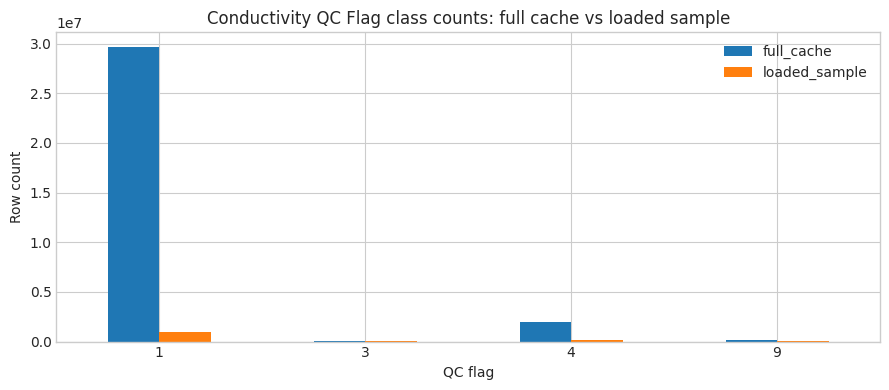

{'active_target': 'Conductivity QC Flag', 'task_mode': 'multiclass'}


In [29]:
# Compare the full-cache target distribution with the sampled training distribution.
full_target_counts = pd.Series({int(key): int(value) for key, value in metadata["target_distribution"].items()}).sort_index()
sample_target_counts = df[TARGET_FLAG].dropna().astype(int).value_counts().sort_index()
task_mode = TASK_MODE.lower().strip()
if task_mode not in {"multiclass", "binary"}:
    raise ValueError(f"Unsupported TASK_MODE: {TASK_MODE}")
target_name = TARGET_FLAG if task_mode == "multiclass" else "issue"

flag_meanings = pd.DataFrame(
    {
        "QC flag": [0, 1, 2, 3, 4, 6, 7, 8, 9],
        "Meaning": [
            "no QC",
            "good",
            "probably good",
            "probably bad",
            "bad",
            "bad down-sampling",
            "averaged",
            "interpolated",
            "missing / NaN",
        ],
    }
)
display(flag_meanings)
distribution_frame = pd.DataFrame({
    "full_cache": full_target_counts,
    "loaded_sample": sample_target_counts,
}).fillna(0).astype(int)
display(distribution_frame)
distribution_frame.plot(kind="bar", figsize=(9, 4), title=f"{TARGET_FLAG} class counts: full cache vs loaded sample")
plt.xlabel("QC flag")
plt.ylabel("Row count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print({"active_target": target_name, "task_mode": task_mode})


### 🧪 Turning The CTD Stream Into Model Features

A machine-learning model does not automatically know that this is a time series from a CTD instrument. We have to decide what each training example looks like.

For the **Random Forest baseline**, we convert the data into a **tabular** problem where each row is one example. We include:

- the raw CTD and derived measurements,
- simple clock features such as hour and day of year,
- `abs_delta` features that measure how sharply each variable changed from the previous row.

This is a useful first step because it is simple, fast, and easy to inspect. It also gives us a good reference point before we try more sophisticated ideas.


In [ ]:
# Reuse the centrally defined measurement list from the configuration cell.
measurement_columns = MEASUREMENT_COLUMNS.copy()

# Start from the efficiently loaded row-level frame.
model_df = df.copy()
model_df["issue"] = model_df[TARGET_FLAG].isin([3, 4, 9]).astype(int)
model_df["hour_utc"] = model_df["Time UTC"].dt.hour
model_df["minute_utc"] = model_df["Time UTC"].dt.minute
model_df["day_of_year"] = model_df["Time UTC"].dt.dayofyear

# Add simple change features so the model can react to sudden local jumps.
for column in measurement_columns:
    engineered_name = f"{column} abs_delta"
    model_df[engineered_name] = model_df[column].diff().abs().fillna(0.0)

feature_columns = measurement_columns + [
    f"{column} abs_delta" for column in measurement_columns
] + ["hour_utc", "minute_utc", "day_of_year"]

model_df = model_df.dropna(subset=[TARGET_FLAG]).reset_index(drop=True)
if MODEL_ROW_LIMIT is not None and len(model_df) > MODEL_ROW_LIMIT:
    # This final cap is scaled by DATA_FRACTION so the whole notebook can be sped up from one variable.
    model_df = evenly_spaced_take(model_df, MODEL_ROW_LIMIT)

model_df["model_target"] = (
    model_df[TARGET_FLAG].astype(int)
    if task_mode == "multiclass"
    else model_df["issue"].astype(int)
)
active_labels = sorted(model_df["model_target"].dropna().astype(int).unique().tolist())

display(model_df[["Time UTC", TARGET_FLAG, "issue", *measurement_columns[:4]]].head(8))
print({"model_rows": len(model_df), "active_labels": active_labels, "feature_count": len(feature_columns)})


## Part 4 — Random Forest

We start with a strong tabular baseline: one row becomes one supervised example, and the forest learns to separate QC classes from engineered numeric features.


### 🌲 Supervised Learning: Random Forest

A **Random Forest** is an ensemble of many decision trees.

Here is the basic idea:

1. make many slightly different training samples from the data,
2. train one decision tree on each sample,
3. let the trees vote on the final class.

Each tree asks simple if/then questions such as:

- is conductivity above some threshold?
- did temperature change sharply?
- is the measurement happening at a particular time of day?

Why this is a good Session 1 model:

- it works well on numeric tabular data,
- it usually needs less feature scaling ceremony than many other models,
- it gives us interpretable outputs such as feature importance.

Limits to keep in mind:

- it does not naturally understand long sequential context,
- it only learns from the features we explicitly give it,
- rare classes can still be difficult.

We also use a **contiguous** train/validation/test split rather than shuffling. That matters for time series because we want the model to be tested on later periods, not on randomly mixed timestamps from the same local run.


![Random Forest bagging illustration](../assets/session1/random_forest_bagging_illustration.png)

Diagram idea: bootstrap samples are drawn from the original dataset, separate trees are trained, and their predictions are aggregated into one model decision.

Image credit: Harry585, Wikimedia Commons, CC BY-SA 4.0. Source: [File:Random Forest Bagging Illustration.png](https://commons.wikimedia.org/wiki/File:Random_Forest_Bagging_Illustration.png)


In [31]:
# Split in time order: earliest -> train, middle -> validation, latest -> test.
train_df, valid_df, test_df = contiguous_split(model_df, TRAIN_FRACTION, VALIDATION_FRACTION)

X_train = train_df[feature_columns]
y_train = train_df["model_target"]
X_valid = valid_df[feature_columns]
y_valid = valid_df["model_target"]
X_test = test_df[feature_columns]
y_test = test_df["model_target"]

print({
    "train_rows": len(train_df),
    "validation_rows": len(valid_df),
    "test_rows": len(test_df),
    "train_time_span": [train_df['Time UTC'].min().isoformat(), train_df['Time UTC'].max().isoformat()],
    "test_time_span": [test_df['Time UTC'].min().isoformat(), test_df['Time UTC'].max().isoformat()],
})


{'train_rows': 700000, 'validation_rows': 150000, 'test_rows': 150000, 'train_time_span': ['2025-03-23T00:00:00.718000+00:00', '2025-12-21T05:16:12.036000+00:00'], 'test_time_span': ['2026-02-06T12:31:15.739000+00:00', '2026-03-26T23:59:59.204000+00:00']}


### Random Forest Settings

These settings control the baseline forest we train below.

Main variables:

- `n_estimators`: number of trees in the forest.
- `max_depth`: maximum depth of each tree. `None` means grow until other stopping rules apply.
- `min_samples_leaf`: minimum number of samples allowed in a leaf.
- `min_samples_split`: minimum number of samples needed to split an internal node.
- `max_features`: how many features each split is allowed to consider. Common choices are `"sqrt"`, `"log2"`, or `None`.
- `class_weight`: how strongly to compensate for imbalance. Common choices are `None`, `"balanced"`, and `"balanced_subsample"`.
- `trees_per_step`: how many trees to add each time we print progress.

Forests do **not** train epoch-by-epoch like neural networks. To make progress visible, we grow the forest in chunks using `warm_start=True` and print the validation F1 after each chunk.

One practical note: when we use `warm_start=True`, this notebook converts `"balanced"` or `"balanced_subsample"` into one fixed class-weight dictionary computed from `y_train`. That avoids a scikit-learn warning and keeps the weighting consistent across growth steps.


In [ ]:
RF_CONFIG = {
    "imputer_strategy": "median",
    "n_estimators": 200,
    "trees_per_step": 25,
    "max_depth": None,
    "min_samples_leaf": 2,
    "min_samples_split": 2,
    "max_features": "sqrt",
    "class_weight": "balanced_subsample",
    "verbose": 0,
}

display(pd.Series(RF_CONFIG, name="value").rename_axis("rf_parameter").to_frame())


In [ ]:
# Step 1: fit the imputer once on training data and reuse it for validation/test.
rf_imputer = SimpleImputer(strategy=RF_CONFIG.get("imputer_strategy", "median"))
X_train_rf = rf_imputer.fit_transform(X_train)
X_valid_rf = rf_imputer.transform(X_valid)
X_test_rf = rf_imputer.transform(X_test)

# Step 2: compute one stable class-weight dictionary for the whole training split.
requested_class_weight = RF_CONFIG.get("class_weight")
if requested_class_weight in {"balanced", "balanced_subsample"}:
    rf_classes = np.array(sorted(pd.Series(y_train).dropna().unique()))
    rf_weight_values = compute_class_weight(
        class_weight="balanced",
        classes=rf_classes,
        y=y_train,
    )
    effective_class_weight = {
        int(label) if isinstance(label, (np.integer, int)) else label: float(weight)
        for label, weight in zip(rf_classes.tolist(), rf_weight_values.tolist())
    }
else:
    effective_class_weight = requested_class_weight

print(
    {
        "requested_class_weight": requested_class_weight,
        "effective_class_weight": effective_class_weight,
    }
)

# Step 3: build the forest itself. We use warm_start so we can grow it in chunks and print progress.
rf_model = RandomForestClassifier(
    n_estimators=RF_CONFIG["trees_per_step"],
    warm_start=True,
    max_depth=RF_CONFIG["max_depth"],
    min_samples_leaf=RF_CONFIG["min_samples_leaf"],
    min_samples_split=RF_CONFIG["min_samples_split"],
    max_features=RF_CONFIG["max_features"],
    class_weight=effective_class_weight,
    n_jobs=-1,
    random_state=SEED,
    verbose=RF_CONFIG["verbose"],
)

rf_progress_rows = []
total_trees = RF_CONFIG["n_estimators"]
trees_per_step = RF_CONFIG["trees_per_step"]
growth_schedule = list(range(trees_per_step, total_trees + 1, trees_per_step))
if not growth_schedule:
    growth_schedule = [total_trees]
elif growth_schedule[-1] != total_trees:
    growth_schedule.append(total_trees)

for tree_count in growth_schedule:
    rf_model.set_params(n_estimators=tree_count)
    rf_model.fit(X_train_rf, y_train)
    current_valid_predictions = rf_model.predict(X_valid_rf)
    current_valid_f1 = f1_score(
        y_valid,
        current_valid_predictions,
        average=report_average(task_mode),
        zero_division=0,
    )
    rf_progress_rows.append({"trees_built": tree_count, "validation_f1": float(current_valid_f1)})
    print(f"Built {tree_count:>3} trees | validation F1 = {current_valid_f1:.4f}")

# Step 4: wrap the fitted pieces into a reusable sklearn pipeline object.
rf_pipeline = Pipeline(
    steps=[
        ("imputer", rf_imputer),
        ("model", rf_model),
    ]
)

valid_predictions = rf_pipeline.predict(X_valid)
test_predictions = rf_pipeline.predict(X_test)
labels = sorted(pd.unique(pd.concat([y_train, y_valid, y_test])))

display(pd.DataFrame(rf_progress_rows))

with RF_MODEL_PATH.open("wb") as handle:
    pickle.dump(
        {
            "pipeline": rf_pipeline,
            "feature_columns": feature_columns,
            "labels": labels,
            "task_mode": task_mode,
        },
        handle,
    )

print({"saved_random_forest_model": str(RF_MODEL_PATH)})


Validation macro/binary F1: 0.5157
              precision    recall  f1-score   support

           1       0.61      1.00      0.75     83136
           3       0.00      0.00      0.00       130
           4       1.00      0.18      0.31     66411
           9       1.00      0.99      1.00       323

    accuracy                           0.64    150000
   macro avg       0.65      0.54      0.52    150000
weighted avg       0.78      0.64      0.56    150000

Test macro/binary F1: 0.6069
              precision    recall  f1-score   support

           1       0.82      1.00      0.90    104854
           3       1.00      0.01      0.02     13313
           4       1.00      0.34      0.51     13919
           9       1.00      1.00      1.00     17914

    accuracy                           0.85    150000
   macro avg       0.96      0.59      0.61    150000
weighted avg       0.88      0.85      0.80    150000



,split,f1
0,validation,0.5157
1,test,0.6069


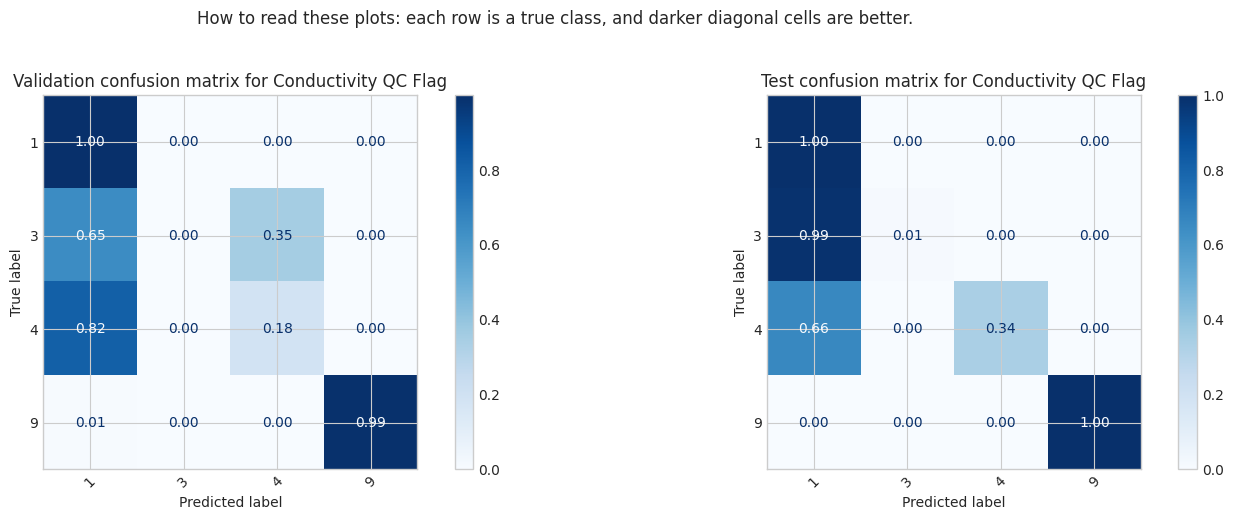

In [34]:
# Report validation and test metrics separately.
metric_rows = []
for split_name, y_true, y_pred in [
    ("validation", y_valid, valid_predictions),
    ("test", y_test, test_predictions),
]:
    split_f1 = f1_score(y_true, y_pred, average=report_average(task_mode), zero_division=0)
    metric_rows.append({"split": split_name, "f1": round(float(split_f1), 4)})
    print(f"{split_name.title()} macro/binary F1: {split_f1:.4f}")
    print(classification_report(y_true, y_pred, labels=labels, zero_division=0))

display(pd.DataFrame(metric_rows))

# Plot normalized confusion matrices for both validation and test.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_predictions,
    labels=labels,
    display_labels=[str(label) for label in labels],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45,
    ax=axes[0],
)
axes[0].set_title(f"Validation confusion matrix for {target_name}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=labels,
    display_labels=[str(label) for label in labels],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=45,
    ax=axes[1],
)
axes[1].set_title(f"Test confusion matrix for {target_name}")
fig.suptitle("How to read these plots: each row is a true class, and darker diagonal cells are better.", y=1.03)
plt.tight_layout()
plt.show()


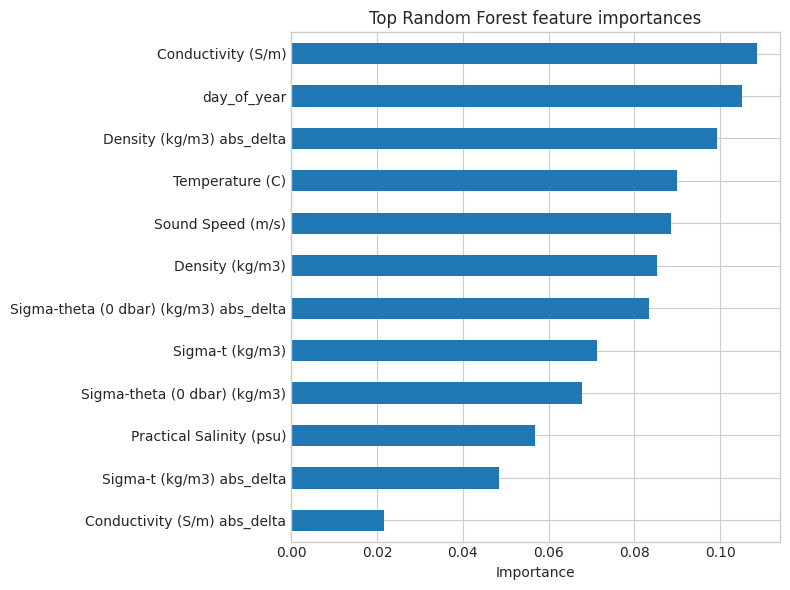

,importance
Conductivity (S/m),0.108488
day_of_year,0.104952
Density (kg/m3) abs_delta,0.099336
Temperature (C),0.089791
Sound Speed (m/s),0.088545
Density (kg/m3),0.085182
Sigma-theta (0 dbar) (kg/m3) abs_delta,0.083310
Sigma-t (kg/m3),0.071243
Sigma-theta (0 dbar) (kg/m3),0.067829
Practical Salinity (psu),0.056786


{'test_errors_shown': 12, 'test_error_rate': 0.1493}


,Time UTC,Conductivity QC Flag,issue,Conductivity (S/m),Temperature (C),Depth (m),prediction,correct
855153,2026-02-08 17:47:37.659000+00:00,4.0,1,3.15504,8.9459,166.29,1,False
855154,2026-02-08 17:47:58.677000+00:00,4.0,1,3.17461,8.9464,166.28,1,False
858406,2026-02-10 02:55:14.291000+00:00,4.0,1,3.30693,9.9906,163.85,1,False
858407,2026-02-10 02:55:18.333000+00:00,4.0,1,3.30634,9.9907,163.85,1,False
858408,2026-02-10 02:55:32.331000+00:00,4.0,1,3.30576,9.9906,163.85,1,False
858409,2026-02-10 02:55:46.290000+00:00,4.0,1,3.30582,9.9908,163.85,1,False
858410,2026-02-10 02:56:00.514000+00:00,4.0,1,3.30577,9.9933,163.85,1,False
858411,2026-02-10 02:56:14.332000+00:00,4.0,1,3.30509,9.9908,163.85,1,False
858412,2026-02-10 02:56:15.282000+00:00,4.0,1,3.30511,9.9908,163.85,1,False
858413,2026-02-10 02:56:28.409000+00:00,4.0,1,3.30492,9.9905,163.85,1,False


In [35]:
# Feature importance tells us which columns the forest used most strongly.
feature_importances = pd.Series(
    rf_pipeline.named_steps["model"].feature_importances_,
    index=feature_columns,
).sort_values(ascending=False)

top_importances = feature_importances.head(12).sort_values()
top_importances.plot(kind="barh", figsize=(8, 6), title="Top Random Forest feature importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
display(feature_importances.head(12).rename("importance").to_frame())

# Show a few test-set mistakes to ground the discussion in real timestamps.
error_frame = test_df[["Time UTC", TARGET_FLAG, "issue", "Conductivity (S/m)", "Temperature (C)", "Depth (m)"]].copy()
error_frame["prediction"] = test_predictions
error_frame["correct"] = error_frame["prediction"] == y_test.to_numpy()
error_examples = error_frame.loc[~error_frame["correct"]].head(12)
print({"test_errors_shown": len(error_examples), "test_error_rate": round(float((~error_frame["correct"]).mean()), 4)})
display(error_examples)


### Date-Range Demo: Predict QC Flags with the Random Forest

The test-set metrics above summarize performance across the whole held-out split. This mini-workflow asks a more concrete question:

**What does the Random Forest predict on one specific interval of time?**

Use UTC strings such as `"2025-09-10 00:00:00Z"` if you want to override the default range.


In [ ]:
RF_RANGE_START = None
RF_RANGE_END = None
RF_AUTO_SELECT_TEST_RANGE = True
RF_MAX_POINTS_TO_PLOT = 800

print(
    {
        "RF_RANGE_START": RF_RANGE_START,
        "RF_RANGE_END": RF_RANGE_END,
        "RF_AUTO_SELECT_TEST_RANGE": RF_AUTO_SELECT_TEST_RANGE,
        "RF_MAX_POINTS_TO_PLOT": RF_MAX_POINTS_TO_PLOT,
    }
)


In [ ]:
rf_range_selection = select_time_range(
    test_df,
    time_column="Time UTC",
    label_column=TARGET_FLAG,
    start=RF_RANGE_START,
    end=RF_RANGE_END,
    auto_select=RF_AUTO_SELECT_TEST_RANGE,
    max_points=RF_MAX_POINTS_TO_PLOT,
)

rf_interval_rows = load_rows_for_time_range(
    metadata,
    row_cache_dir=Path(ROW_CACHE_DIR),
    start=rf_range_selection["start"],
    end=rf_range_selection["end"],
    columns=ROW_USE_COLUMNS,
)

if rf_interval_rows.empty:
    print("No row-level data was found in the requested Random Forest range.")
else:
    rf_interval_model_df, _, _ = build_model_frame(
        rf_interval_rows,
        target_flag=TARGET_FLAG,
        task_mode=task_mode,
        model_row_limit=None,
    )
    rf_interval_model_df = rf_interval_model_df[
        (rf_interval_model_df["Time UTC"] >= rf_range_selection["start"])
        & (rf_interval_model_df["Time UTC"] <= rf_range_selection["end"])
    ].reset_index(drop=True)

    if rf_interval_model_df.empty:
        print("The selected Random Forest range did not contain usable labeled rows after preparation.")
    else:
        rf_interval_predictions = rf_pipeline.predict(rf_interval_model_df[feature_columns])
        rf_interval_origin = infer_interval_origin(
            rf_range_selection["start"],
            rf_range_selection["end"],
            {"train": train_df, "validation": valid_df, "test": test_df},
        )
        rf_interval_metrics = compute_interval_classification_metrics(
            rf_interval_model_df["model_target"],
            rf_interval_predictions,
            labels=labels,
            average=report_average(task_mode),
            target_names=[str(label) for label in labels],
        )
        rf_plot_palette = DEFAULT_FLAG_PALETTE if task_mode == "multiclass" else {0: "#1f77b4", 1: "#d62728"}
        rf_true_intervals = build_labeled_intervals(
            rf_interval_model_df,
            time_column="Time UTC",
            label_column="model_target",
        )
        rf_pred_frame = rf_interval_model_df[["Time UTC"]].copy()
        rf_pred_frame["predicted_label"] = rf_interval_predictions
        rf_pred_intervals = build_labeled_intervals(
            rf_pred_frame,
            time_column="Time UTC",
            label_column="predicted_label",
        )

        print(
            {
                "selection_mode": rf_range_selection["selection_mode"],
                "selected_priority_flag": rf_range_selection["selected_label"],
                "interval_origin": rf_interval_origin,
                "range_start": rf_range_selection["start"].isoformat(),
                "range_end": rf_range_selection["end"].isoformat(),
                "rows_in_interval": int(len(rf_interval_model_df)),
                "interval_f1": rf_interval_metrics["f1"],
            }
        )
        print(rf_interval_metrics["report_text"])

        display(
            pd.DataFrame(
                {
                    "true_count": pd.Series(rf_interval_model_df["model_target"]).value_counts().sort_index(),
                    "predicted_count": pd.Series(rf_interval_predictions).value_counts().sort_index(),
                }
            ).fillna(0).astype(int)
        )

        rf_demo_figure = plot_time_series_with_bands(
            rf_interval_model_df,
            band_specs=[
                {"title": "True flags", "intervals": rf_true_intervals, "palette": rf_plot_palette},
                {"title": "RF predictions", "intervals": rf_pred_intervals, "palette": rf_plot_palette},
            ],
            measurement_column="Conductivity (S/m)",
            secondary_column="Temperature (C)",
            max_points=RF_MAX_POINTS_TO_PLOT,
            title="Random Forest predictions on a selected time range",
        )
        plt.show()

        rf_cm_fig, rf_cm_ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix=rf_interval_metrics["confusion_matrix"],
            display_labels=rf_interval_metrics["display_labels"],
        ).plot(ax=rf_cm_ax, cmap="Blues", colorbar=False)
        rf_cm_ax.set_title("Random Forest confusion matrix on the selected range")
        plt.tight_layout()
        plt.show()


        ### Reflection Questions: Random Forest

        1. Which input features seem most responsible for the mistakes in this interval: raw measurements, change features, or time-of-day features?
2. Do the errors line up with the class imbalance we saw earlier, or do they suggest a different modeling problem?
3. If you wanted to improve this interval specifically, would you change the features, the target, or the forest settings first?

        Add your own notes or follow-up questions here:

        - 
        - 
        - 


### Random Forest: Tune The Forest, Then Rethink The Features

This section stays entirely inside the Random Forest part of the workflow.

The lesson is deliberate:

1. start with a reasonable baseline forest,
2. tune the forest hyperparameters on a validation split,
3. then ask the more important question: are we feeding the model the right information?

In many tabular ML problems, feature preparation and target definition matter more than squeezing a few extra points from `n_estimators` or `max_depth`.


In [ ]:
RF_SEARCH_SPACE = {
    "n_estimators": [250, 400],
    "max_depth": [18, None],
    "min_samples_leaf": [1],
    "min_samples_split": [2],
    "max_features": ["sqrt"],
    "class_weight": ["balanced_subsample"],
}

BASE_RF_SEARCH_MODEL_ROW_LIMIT = 500000
RF_SEARCH_MODEL_ROW_LIMIT = max(200000, int(BASE_RF_SEARCH_MODEL_ROW_LIMIT * DATA_FRACTION))
BEST_RF_SEARCH_CONFIG = None

print({"RUN_HYPERPARAMETER_SEARCH": RUN_HYPERPARAMETER_SEARCH})
print({"rf_trials": 4, "rf_search_model_row_limit": RF_SEARCH_MODEL_ROW_LIMIT})


In [ ]:
if RUN_HYPERPARAMETER_SEARCH:
    rf_search_model_df = evenly_spaced_take(model_df, RF_SEARCH_MODEL_ROW_LIMIT)
    rf_search_train_df, rf_search_valid_df, _ = contiguous_split(
        rf_search_model_df,
        train_fraction=TRAIN_FRACTION,
        validation_fraction=VALIDATION_FRACTION,
    )
    rf_search_labels = sorted(rf_search_model_df["model_target"].dropna().astype(int).unique().tolist())

    rf_search_results, _, _ = run_rf_search(
        rf_search_train_df,
        rf_search_valid_df,
        feature_columns,
        labels=rf_search_labels,
        task_mode=task_mode,
        seed=SEED,
        search_space=RF_SEARCH_SPACE,
    )
    display(rf_search_results.head(10))

    rf_candidate_keys = [
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "max_features",
        "class_weight",
    ]
    rf_transfer_rows = []
    for _, candidate_row in rf_search_results.head(2).iterrows():
        candidate_config = {}
        for key in rf_candidate_keys:
            value = candidate_row[key]
            if key in {"n_estimators", "min_samples_leaf", "min_samples_split"}:
                candidate_config[key] = int(value)
            elif key == "max_depth":
                candidate_config[key] = None if pd.isna(value) else int(value)
            else:
                candidate_config[key] = value
        candidate_model = fit_random_forest(
            train_df,
            feature_columns,
            seed=SEED,
            config=candidate_config,
        )
        candidate_valid = evaluate_classifier(
            candidate_model,
            valid_df,
            feature_columns,
            labels=rf_search_labels,
            task_mode=task_mode,
        )
        candidate_test = evaluate_classifier(
            candidate_model,
            test_df,
            feature_columns,
            labels=rf_search_labels,
            task_mode=task_mode,
        )
        rf_transfer_rows.append(
            {
                "config": candidate_config,
                "validation_f1": candidate_valid["f1"],
                "test_f1": candidate_test["f1"],
            }
        )

    rf_transfer_frame = pd.DataFrame(rf_transfer_rows).sort_values("validation_f1", ascending=False).reset_index(drop=True)
    BEST_RF_SEARCH_CONFIG = rf_transfer_frame.iloc[0]["config"]
    display(rf_transfer_frame)
else:
    print("RF hyperparameter search skipped. Keeping the baseline forest settings.")

print({"BEST_RF_SEARCH_CONFIG": BEST_RF_SEARCH_CONFIG})


### Beyond Random Forest: Better Features, Better Tree Families, Better Targets

The Random Forest section above teaches the baseline workflow. The next question is how to improve it without jumping straight to a neural network.

A useful way to think about tree-model improvement is:

1. **Add more context**. If a single row is not enough, give the model lags and rolling summaries.
2. **Try a stronger tree family**. Random Forest is not the only bagged-tree option; ExtraTrees can work better on noisy tabular data.
3. **Revisit the target itself**. If labels are ambiguous, collapsing some classes may produce a model that is both easier to learn and closer to the operational decision.

The cells below use the local experiments we just ran to show this process explicitly.


In [ ]:
# Build the same context features used in the local tree-comparison experiments.
advanced_model_df, context_feature_columns = add_temporal_context_features(model_df)
lag_examples = [name for name in context_feature_columns if " lag_" in name][:12]
rolling_examples = [name for name in context_feature_columns if " roll_" in name][:12]
context_feature_examples = pd.DataFrame(
    [
        *[{"feature_group": "lag", "feature_name": name} for name in lag_examples],
        *[{"feature_group": "rolling", "feature_name": name} for name in rolling_examples],
    ]
)

print(
    {
        "base_feature_count": len(feature_columns),
        "new_context_feature_count": len(context_feature_columns),
        "total_feature_count_if_used": len(feature_columns) + len(context_feature_columns),
    }
)
display(context_feature_examples)


### Tree Family Comparison

We compared:

- the baseline Random Forest,
- Random Forest plus temporal context features,
- ExtraTrees plus the same context features,
- and a gradient-boosted tree baseline.

The key teaching point is not just *which model won*. It is *why*:

- context features gave the tree models access to short-term history,
- ExtraTrees handled the noisy tabular signal better than the baseline forest,
- and we checked performance on the same time-based splits rather than trusting one lucky number.


In [ ]:
tree_search_path = ARTIFACT_DIR / "tree_model_comparison_search.csv"
tree_full_path = ARTIFACT_DIR / "tree_model_comparison_full.csv"

if tree_search_path.exists() and tree_full_path.exists():
    tree_search_results = pd.read_csv(tree_search_path)
    tree_full_results = pd.read_csv(tree_full_path)

    display(
        tree_search_results[
            [
                "name",
                "family",
                "feature_variant",
                "validation_f1",
                "test_f1",
                "validation_class_4_recall",
                "test_class_4_recall",
            ]
        ]
    )
    display(
        tree_full_results[
            [
                "name",
                "family",
                "feature_variant",
                "validation_f1",
                "test_f1",
                "validation_class_4_recall",
                "test_class_4_recall",
            ]
        ]
    )
else:
    print(
        "Advanced tree comparison artifacts are not included in the participant repo. "
        "This section uses instructor-prepared offline comparison results when they are available."
    )


### Target Design: Should We Collapse Ambiguous Flags?

Another important modeling decision is whether the original label set is the right one.

For this dataset, `3` and `4` are both problem cases, while `9` means the value is missing. Depending on the operational question, it can be more useful to predict:

- the original `1 / 3 / 4 / 9` labels,
- a collapsed `1 / 34 / 9` target,
- or a binary `good vs issue` target.

This is not just a modeling trick. It is a problem-definition question. A simpler target can be much easier to learn and may align better with the real decision you need to automate.


In [ ]:
strategy_summary_path = ARTIFACT_DIR / "extratrees_strategy_summary.json"
strategy_results_path = ARTIFACT_DIR / "extratrees_target_strategy_comparison.csv"
collapsed_metrics_path = ARTIFACT_DIR / "collapsed_target_per_class_metrics.md"

if strategy_results_path.exists():
    strategy_results = pd.read_csv(strategy_results_path)
    display(strategy_results)
else:
    print(
        "Target-strategy comparison artifacts are not included in the participant repo. "
        "This section uses instructor-prepared offline comparison results when they are available."
    )

per_class_tables = []
for csv_name, strategy_name, split_name in [
    ("collapsed_1_34_9_validation_per_class_metrics.csv", "collapsed_1_34_9", "validation"),
    ("collapsed_1_34_9_test_per_class_metrics.csv", "collapsed_1_34_9", "test"),
    ("binary_issue_validation_per_class_metrics.csv", "binary_issue", "validation"),
    ("binary_issue_test_per_class_metrics.csv", "binary_issue", "test"),
]:
    csv_path = ARTIFACT_DIR / csv_name
    if csv_path.exists():
        frame = pd.read_csv(csv_path)
        frame.insert(0, "strategy", strategy_name)
        frame.insert(1, "split", split_name)
        per_class_tables.append(frame)

if per_class_tables:
    display(pd.concat(per_class_tables, ignore_index=True))
else:
    print(
        "Per-class collapsed-target metric artifacts are not included in the participant repo."
    )


### What We Learned From The Advanced Tree Experiments

The main lessons from these local experiments were:

- **More data helped**, but only modestly for the full 4-class problem.
- **Temporal context features helped more** because the QC issues often occur in short coherent runs.
- **ExtraTrees outperformed the baseline Random Forest** in this setting.
- **Collapsing ambiguous labels helped dramatically**, especially for `1 / 34 / 9` and binary `issue` detection.

This is exactly the kind of modeling mindset we want in Session 2:

- do not assume the first feature set is enough,
- do not assume the first model family is the best,
- and do not assume the original label definition is the most useful one.


## Part 5 — k-means

Next we switch to an unsupervised lens: instead of predicting flags directly, we group windows with similar summary behavior and interpret those clusters.


########## 🧭 Unsupervised Learning: k-means On Window Features

Supervised learning uses labels. Unsupervised learning does **not**.

Here we use **k-means**, which groups windows into clusters based on similarity in feature space. The cluster IDs themselves do not carry meaning ahead of time. We interpret them *after* fitting by looking at:

- how many windows ended up in each cluster,
- the mean issue rate inside each cluster,
- where the cluster sits in feature space.

This is useful when you want to surface interesting periods even before a label model is mature.

One subtle point: the cluster **numbers and colours are arbitrary**. They only become meaningful after we interpret them using the legend and summary statistics.

Good reference if you want more detail: [scikit-learn k-means documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)


### 🔎 k-means Settings

Main variables:

- `n_clusters`: how many clusters we ask the algorithm to find.
- `n_init`: how many random initializations to try. `"auto"` is a good default in current scikit-learn.

If participants want to experiment, the most useful first change is usually `n_clusters`.


In [ ]:
KMEANS_CONFIG = {
    "n_clusters": 5,
    "n_init": "auto",
}

KMEANS_EXAMPLES_PER_CLUSTER = 1
KMEANS_EXAMPLE_CONTEXT_POINTS = 1500
KMEANS_EXAMPLE_HIGHLIGHT_ALPHA = 0.22

display(pd.Series(KMEANS_CONFIG, name="value").rename_axis("kmeans_parameter").to_frame())
print(
    {
        "KMEANS_EXAMPLES_PER_CLUSTER": KMEANS_EXAMPLES_PER_CLUSTER,
        "KMEANS_EXAMPLE_CONTEXT_POINTS": KMEANS_EXAMPLE_CONTEXT_POINTS,
        "KMEANS_EXAMPLE_HIGHLIGHT_ALPHA": KMEANS_EXAMPLE_HIGHLIGHT_ALPHA,
    }
)


In [ ]:
# Build the feature matrix from window-level means and standard deviations.
cluster_feature_columns = [
    column
    for column in window_df.columns
    if column.endswith("_mean") or column.endswith("_std")
]

cluster_input = window_df[cluster_feature_columns]
cluster_input = pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(cluster_input),
    columns=cluster_feature_columns,
)
cluster_scaled = StandardScaler().fit_transform(cluster_input)

# Fit k-means.
kmeans = KMeans(
    n_clusters=KMEANS_CONFIG["n_clusters"],
    random_state=SEED,
    n_init=KMEANS_CONFIG["n_init"],
)
window_df["cluster"] = kmeans.fit_predict(cluster_scaled)
window_df["distance_to_centroid"] = kmeans.transform(cluster_scaled).min(axis=1)

cluster_summary = (
    window_df.groupby("cluster")
    .agg(
        window_count=("cluster", "size"),
        mean_issue_rate=("issue_rate", "mean"),
        max_issue_rate=("issue_rate", "max"),
        avg_distance=("distance_to_centroid", "mean"),
        first_window=("window_start", "min"),
        last_window=("window_end", "max"),
    )
    .sort_index()
)
display(cluster_summary.round({"mean_issue_rate": 3, "max_issue_rate": 3, "avg_distance": 3}))


In [ ]:
# Plot a readable sample of windows so the scatter does not become an unreadable blob.
plot_window_df = evenly_spaced_take(window_df.sort_values("window_start"), 5000)
cluster_ids = sorted(cluster_summary.index.tolist())
cluster_colors = plt.cm.tab10(np.linspace(0, 1, len(cluster_ids)))
cluster_palette = {cluster_id: cluster_colors[idx] for idx, cluster_id in enumerate(cluster_ids)}

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
cluster_centers = (
    plot_window_df.groupby("cluster")[["Conductivity (S/m)_mean", "Temperature (C)_mean"]]
    .mean()
    .reindex(cluster_ids)
)

# Left panel: scatter in feature space with a real legend.
legend_handles = []
for cluster_id in cluster_ids:
    subset = plot_window_df[plot_window_df["cluster"] == cluster_id]
    axes[0].scatter(
        subset["Conductivity (S/m)_mean"],
        subset["Temperature (C)_mean"],
        s=18,
        alpha=0.55,
        color=cluster_palette[cluster_id],
        edgecolors="none",
    )
    axes[0].scatter(
        cluster_centers.loc[cluster_id, "Conductivity (S/m)_mean"],
        cluster_centers.loc[cluster_id, "Temperature (C)_mean"],
        s=220,
        marker="*",
        color=cluster_palette[cluster_id],
        edgecolors="black",
        linewidths=0.8,
    )
    legend_handles.append(
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=cluster_palette[cluster_id],
            markersize=8,
            label=(
                f"Cluster {cluster_id} | n={int(cluster_summary.loc[cluster_id, 'window_count'])} | "
                f"mean issue={cluster_summary.loc[cluster_id, 'mean_issue_rate']:.2f}"
            ),
        )
    )

axes[0].set_title("k-means clusters in window feature space")
axes[0].set_xlabel("Conductivity mean (S/m)")
axes[0].set_ylabel("Temperature mean (C)")
axes[0].grid(alpha=0.25)
axes[0].legend(handles=legend_handles, title="Cluster legend", loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True)

# Right panel: bar chart is easier to read than a dense histogram for this audience.
bar_positions = np.arange(len(cluster_ids))
bar_values = [cluster_summary.loc[cluster_id, "mean_issue_rate"] for cluster_id in cluster_ids]
bar_colors = [cluster_palette[cluster_id] for cluster_id in cluster_ids]
axes[1].bar(bar_positions, bar_values, color=bar_colors, edgecolor="black", linewidth=0.6)
axes[1].set_xticks(bar_positions)
axes[1].set_xticklabels([f"Cluster {cluster_id}" for cluster_id in cluster_ids], rotation=30)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Mean issue rate")
axes[1].set_title("Average issue rate by cluster")
for idx, cluster_id in enumerate(cluster_ids):
    axes[1].text(
        idx,
        bar_values[idx] + 0.02,
        f"n={int(cluster_summary.loc[cluster_id, 'window_count'])}\n{bar_values[idx]:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

interesting_windows = window_df.sort_values(
    ["issue_rate", "distance_to_centroid"],
    ascending=[False, False],
).head(10)
interesting_windows = interesting_windows[["window_start", "window_end", "source_file", "cluster", "issue_rate", "distance_to_centroid"]].copy()
interesting_windows["source_file"] = interesting_windows["source_file"].str.replace(
    r"_\d{8}T\d{6}Z_\d{8}T\d{6}Z-NaN\.csv$",
    "",
    regex=True,
)
display(interesting_windows.round({"issue_rate": 3, "distance_to_centroid": 3}))


### Looking At Real Time-Series Windows From Each Cluster

The scatter plot shows where clusters sit in feature space, but it does not show what the underlying CTD behavior actually looked like.

The next plot closes that loop. For each cluster, we pick a representative window that sits close to its centroid, then:

- show a wider time-series context from the original row-level parquet,
- highlight the exact window used in k-means,
- mark the datapoints inside that highlighted window.

This makes it much easier to interpret clusters as real operating regimes rather than abstract colored dots.


In [ ]:
cluster_example_figure, cluster_example_windows = plot_cluster_window_examples(
    window_df,
    source_to_row_part=source_to_row_part,
    measurement_column="Conductivity (S/m)",
    secondary_column="Temperature (C)",
    examples_per_cluster=KMEANS_EXAMPLES_PER_CLUSTER,
    context_points=KMEANS_EXAMPLE_CONTEXT_POINTS,
    highlight_alpha=KMEANS_EXAMPLE_HIGHLIGHT_ALPHA,
)
plt.show()
display(cluster_example_windows)


### Date-Range Demo: See Which Clusters Appear in a Specific Interval

k-means does not predict QC flags directly. Instead, it groups short windows with similar summary behavior.

This demo lets us ask: **what kinds of windows show up inside one selected time range, and how do their issue rates differ?**


In [ ]:
KMEANS_RANGE_START = None
KMEANS_RANGE_END = None
KMEANS_AUTO_SELECT_TEST_RANGE = True
KMEANS_MAX_POINTS_TO_PLOT = 800

print(
    {
        "KMEANS_RANGE_START": KMEANS_RANGE_START,
        "KMEANS_RANGE_END": KMEANS_RANGE_END,
        "KMEANS_AUTO_SELECT_TEST_RANGE": KMEANS_AUTO_SELECT_TEST_RANGE,
        "KMEANS_MAX_POINTS_TO_PLOT": KMEANS_MAX_POINTS_TO_PLOT,
    }
)


In [ ]:
kmeans_range_selection = select_time_range(
    test_df,
    time_column="Time UTC",
    label_column=TARGET_FLAG,
    start=KMEANS_RANGE_START,
    end=KMEANS_RANGE_END,
    auto_select=KMEANS_AUTO_SELECT_TEST_RANGE,
    max_points=KMEANS_MAX_POINTS_TO_PLOT,
)

kmeans_interval_rows = load_rows_for_time_range(
    metadata,
    row_cache_dir=Path(ROW_CACHE_DIR),
    start=kmeans_range_selection["start"],
    end=kmeans_range_selection["end"],
    columns=ROW_USE_COLUMNS,
)
kmeans_interval_windows = window_df[
    (window_df["window_start"] <= kmeans_range_selection["end"])
    & (window_df["window_end"] >= kmeans_range_selection["start"])
].copy()

if kmeans_interval_rows.empty or kmeans_interval_windows.empty:
    print("No overlapping k-means windows were found in the requested range.")
else:
    kmeans_interval_origin = infer_interval_origin(
        kmeans_range_selection["start"],
        kmeans_range_selection["end"],
        {"train": train_df, "validation": valid_df, "test": test_df},
    )
    kmeans_interval_intervals = merge_adjacent_intervals(
        kmeans_interval_windows.rename(
            columns={"window_start": "start", "window_end": "end", "cluster": "label"}
        )[["start", "end", "label"]]
    )
    kmeans_cluster_counts = (
        kmeans_interval_windows.groupby("cluster")
        .agg(
            window_count=("cluster", "size"),
            mean_issue_rate=("issue_rate", "mean"),
            max_issue_rate=("issue_rate", "max"),
        )
        .sort_index()
    )

    print(
        {
            "selection_mode": kmeans_range_selection["selection_mode"],
            "selected_priority_flag": kmeans_range_selection["selected_label"],
            "interval_origin": kmeans_interval_origin,
            "range_start": kmeans_range_selection["start"].isoformat(),
            "range_end": kmeans_range_selection["end"].isoformat(),
            "row_points_in_interval": int(len(kmeans_interval_rows)),
            "window_count_in_interval": int(len(kmeans_interval_windows)),
        }
    )
    display(kmeans_cluster_counts.round(3))

    kmeans_demo_figure = plot_time_series_with_bands(
        kmeans_interval_rows,
        band_specs=[
            {
                "title": "k-means clusters",
                "intervals": kmeans_interval_intervals,
                "palette": cluster_palette,
            }
        ],
        measurement_column="Conductivity (S/m)",
        secondary_column="Temperature (C)",
        max_points=KMEANS_MAX_POINTS_TO_PLOT,
        title="k-means cluster assignments on a selected time range",
    )
    plt.show()


        ### Reflection Questions: k-means

        1. Do these cluster spans look like real operating regimes, or do some clusters still seem hard to interpret physically?
2. If you changed `n_clusters`, which regions in this interval do you expect would split apart or merge together?
3. How closely do the cluster spans line up with QC-flag changes, and what does that say about the usefulness of unsupervised learning here?

        Add your own notes or follow-up questions here:

        - 
        - 
        - 


## Part 6 — 1D CNN

Now we keep short stretches of signal together as one training example and see how a sequence model behaves when it learns local time patterns directly.


### Sequential Model: 1D CNN

A **convolutional neural network (CNN)** applies small learnable filters across an ordered signal. For images that order is two-dimensional. In this notebook, the order is **time**.

The key idea is:

1. a short filter looks at a local pattern,
2. the same filter slides across the whole sequence,
3. later layers combine those detected patterns into a final prediction.

For this CTD task, a 1D CNN can learn patterns such as:

- sudden spikes or drops,
- flat segments,
- repeated local shapes across several sensor channels.

Why this is useful here:

- Random Forest treats each row mostly as a tabular snapshot,
- CNN keeps a short stretch of signal together as one example,
- the training loop also gives us a chance to teach batching, validation checkpoints, and early stopping.

The CNN section runs by default in this notebook and follows standard training practice:

- train / validation / test split,
- class-aware loss weighting,
- best-checkpoint saving based on validation F1,
- early stopping,
- mini-batch training through `DataLoader`,
- pinned-memory and multi-worker loading when the local machine supports it.

Useful references: [PyTorch tutorial on defining neural networks](https://docs.pytorch.org/tutorials/beginner/blitz/neural_networks_tutorial), [PyTorch DataLoader docs](https://pytorch.org/docs/stable/data.html), [PyTorch performance tuning guide](https://pytorch.org/tutorials/recipes/recipes/tuning_guide.html)


![Convolutional network diagram](../assets/session1/convolutional_network.png)

Diagram idea: small filters slide across the input, produce feature maps, and later layers combine those maps into a final prediction.

In this notebook the same logic is applied to **1D time windows** rather than 2D images.

Image credit: Aphex34, Wikimedia Commons, CC BY-SA 4.0. Source: [File:Convolutional Network.png](https://commons.wikimedia.org/wiki/File:Convolutional_Network.png)


### 🎛️ CNN Settings

These settings control the baseline 1D CNN and its training loop.

Model-shape variables:

- `window_size`: number of time steps in each training window.
- `conv_channels`: number of filters in each convolution layer.
- `dropout`: dropout probability used for regularization.
- `label_reduction`: how row-level labels become one window label. Here we use `"worst"`.

Optimization variables:

- `epochs`: maximum number of passes through the training data.
- `batch_size`: number of windows per optimization step.
- `learning_rate`: optimizer step size.
- `weight_decay`: L2-style regularization for the optimizer.
- `patience` and `min_delta`: early-stopping controls.
- `lr_decay_factor` and `lr_patience`: learning-rate scheduler controls.
- `gradient_clip_norm`: cap on gradient size to stabilize training.

DataLoader variables:

- `num_workers`: worker processes for loading batches.
- `pin_memory`: can speed up host-to-GPU transfer.
- `persistent_workers`: keeps workers alive between epochs.
- `prefetch_factor`: how many batches each worker prepares ahead of time.


In [ ]:
CNN_CONFIG = {
    "window_size": 128,
    "epochs": 10,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "patience": 3,
    "min_delta": 0.001,
    "dropout": 0.2,
    "lr_decay_factor": 0.5,
    "lr_patience": 1,
    "gradient_clip_norm": 1.0,
    "conv_channels": [32, 64],
    "label_reduction": "worst",
}

CNN_LOADER_CONFIG = {
    "num_workers": min(4, os.cpu_count() or 1),
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
}

display(pd.Series(CNN_CONFIG, name="value").rename_axis("cnn_parameter").to_frame())
display(pd.Series(CNN_LOADER_CONFIG, name="value").rename_axis("loader_parameter").to_frame())


### CNN Step 1: Turn Rows into Windows

A CNN expects a fixed-size tensor, not an arbitrary-length table.

In this step we:

- collect the measurement columns we want to model,
- group consecutive rows into fixed windows,
- reduce many row-level QC flags into one window label,
- split the windows in time order into train, validation, and test groups,
- normalize each sensor channel using only the training split.

This is a good place to pause in a live session and ask: what information do we lose when we compress several row labels into one window label?


In [ ]:
if not RUN_CNN_APPENDIX:
    print("CNN appendix skipped. Set RUN_CNN_APPENDIX = True in the configuration cell to enable it.")
    CNN_READY = False
else:
    try:
        import torch
        from torch import nn
        from torch.utils.data import DataLoader, TensorDataset
        CNN_READY = True
        print({
            "torch": torch.__version__,
            "cuda_available": torch.cuda.is_available(),
            "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        })
    except ImportError as exc:
        CNN_READY = False
        print("PyTorch is not installed in this environment.")
        raise SystemExit(exc)


In [ ]:
if not CNN_READY:
    CNN_RUN = False
    print("CNN training cell skipped.")
else:
    # Build fixed windows from the row-level sample.
    WINDOW_SIZE = CNN_CONFIG["window_size"]
    cnn_df = model_df[measurement_columns + ["model_target"]].copy().dropna().reset_index(drop=True)
    usable_rows = (len(cnn_df) // WINDOW_SIZE) * WINDOW_SIZE
    cnn_df = cnn_df.iloc[:usable_rows]

    raw_sequences = cnn_df[measurement_columns].to_numpy(dtype=np.float32).reshape(
        -1,
        WINDOW_SIZE,
        len(measurement_columns),
    )
    raw_window_targets = cnn_df["model_target"].to_numpy().reshape(-1, WINDOW_SIZE)

    if task_mode == "multiclass":
        window_targets = np.array(
            [reduce_window_target(row, mode=CNN_CONFIG["label_reduction"]) for row in raw_window_targets],
            dtype=np.int64,
        )
        class_labels = sorted(np.unique(window_targets).tolist())
        label_to_index = {label: index for index, label in enumerate(class_labels)}
        encoded_targets = np.array([label_to_index[label] for label in window_targets], dtype=np.int64)
    else:
        class_labels = [0, 1]
        encoded_targets = raw_window_targets.max(axis=1).astype(np.float32)

    # Move to channel-first layout expected by Conv1D.
    sequences = np.transpose(raw_sequences, (0, 2, 1))

    # Keep the split contiguous in time so validation and test remain realistic.
    train_end = int(len(sequences) * TRAIN_FRACTION)
    valid_end = int(len(sequences) * (TRAIN_FRACTION + VALIDATION_FRACTION))
    X_train = sequences[:train_end]
    X_valid = sequences[train_end:valid_end]
    X_test = sequences[valid_end:]
    y_train = encoded_targets[:train_end]
    y_valid = encoded_targets[train_end:valid_end]
    y_test = encoded_targets[valid_end:]

    # Normalize each sensor channel using only the training split.
    channel_mean = X_train.mean(axis=(0, 2), keepdims=True)
    channel_std = X_train.std(axis=(0, 2), keepdims=True) + 1e-6
    X_train = (X_train - channel_mean) / channel_std
    X_valid = (X_valid - channel_mean) / channel_std
    X_test = (X_test - channel_mean) / channel_std

    CNN_RUN = True
    print(
        {
            "windows_total": int(len(sequences)),
            "train_windows": int(len(X_train)),
            "validation_windows": int(len(X_valid)),
            "test_windows": int(len(X_test)),
            "window_size": int(WINDOW_SIZE),
            "channels": int(len(measurement_columns)),
        }
    )


### CNN Step 2: Build the Model and the DataLoaders

Here we create four pieces:

- the neural network itself,
- the loss function,
- the optimizer and learning-rate scheduler,
- the `DataLoader` objects that stream mini-batches during training.

Notice that the `DataLoader` keeps the full dataset in CPU memory and feeds the GPU one batch at a time. That is usually much more efficient than trying to move every window onto the GPU all at once.


In [ ]:
if not CNN_RUN:
    print("CNN model setup skipped.")
else:
    torch.manual_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True

    class TinyQCNet(nn.Module):
        def __init__(self, channels: int, output_dim: int) -> None:
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv1d(channels, CNN_CONFIG["conv_channels"][0], kernel_size=7, padding=3),
                nn.ReLU(),
                nn.Conv1d(CNN_CONFIG["conv_channels"][0], CNN_CONFIG["conv_channels"][1], kernel_size=5, padding=2),
                nn.ReLU(),
                nn.Dropout(CNN_CONFIG["dropout"]),
                nn.AdaptiveAvgPool1d(1),
                nn.Flatten(),
                nn.Linear(CNN_CONFIG["conv_channels"][1], output_dim),
            )

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.net(x)

    if task_mode == "multiclass":
        train_targets_tensor = torch.from_numpy(y_train).long()
        valid_targets_tensor = torch.from_numpy(y_valid).long()
        test_targets_tensor = torch.from_numpy(y_test).long()
        class_counts = np.bincount(y_train, minlength=len(class_labels)).clip(min=1)
        class_weights = len(y_train) / (len(class_counts) * class_counts)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
        output_dim = len(class_labels)
    else:
        train_targets_tensor = torch.from_numpy(y_train.astype(np.float32))
        valid_targets_tensor = torch.from_numpy(y_valid.astype(np.float32))
        test_targets_tensor = torch.from_numpy(y_test.astype(np.float32))
        positive_count = max(float(y_train.sum()), 1.0)
        negative_count = max(float(len(y_train) - y_train.sum()), 1.0)
        pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32, device=device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        output_dim = 1

    train_dataset = TensorDataset(torch.from_numpy(X_train).float(), train_targets_tensor)
    valid_dataset = TensorDataset(torch.from_numpy(X_valid).float(), valid_targets_tensor)
    test_dataset = TensorDataset(torch.from_numpy(X_test).float(), test_targets_tensor)

    loader_kwargs = {}
    num_workers = int(CNN_LOADER_CONFIG["num_workers"])
    if num_workers > 0:
        loader_kwargs["num_workers"] = num_workers
        loader_kwargs["persistent_workers"] = bool(CNN_LOADER_CONFIG["persistent_workers"])
        loader_kwargs["prefetch_factor"] = int(CNN_LOADER_CONFIG["prefetch_factor"])
    if CNN_LOADER_CONFIG["pin_memory"]:
        loader_kwargs["pin_memory"] = True
    use_non_blocking = bool(loader_kwargs.get("pin_memory", False) and device.type == "cuda")

    train_loader = DataLoader(
        train_dataset,
        batch_size=CNN_CONFIG["batch_size"],
        shuffle=True,
        **loader_kwargs,
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=CNN_CONFIG["batch_size"],
        shuffle=False,
        **loader_kwargs,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=CNN_CONFIG["batch_size"],
        shuffle=False,
        **loader_kwargs,
    )

    model = TinyQCNet(channels=len(measurement_columns), output_dim=output_dim).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CNN_CONFIG["learning_rate"],
        weight_decay=CNN_CONFIG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=CNN_CONFIG["lr_decay_factor"],
        patience=CNN_CONFIG["lr_patience"],
    )

    best_metric = -np.inf
    best_epoch = 0
    patience_counter = 0
    history = []
    best_state = None

    def run_epoch(loader, training: bool) -> tuple[float, np.ndarray, np.ndarray]:
        model.train(training)
        total_loss = 0.0
        predictions = []
        targets = []
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=use_non_blocking)
            batch_y = batch_y.to(device, non_blocking=use_non_blocking)
            with torch.set_grad_enabled(training):
                logits = model(batch_x)
                if task_mode == "multiclass":
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = logits.argmax(dim=1)
                else:
                    logits = logits.squeeze(-1)
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = (torch.sigmoid(logits) >= 0.5).long()
                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    if CNN_CONFIG["gradient_clip_norm"]:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), CNN_CONFIG["gradient_clip_norm"])
                    optimizer.step()
            total_loss += float(loss.item()) * len(batch_x)
            predictions.append(batch_predictions.detach().cpu().numpy())
            targets.append(batch_y.detach().cpu().numpy())
        predictions_array = np.concatenate(predictions) if predictions else np.array([])
        targets_array = np.concatenate(targets) if targets else np.array([])
        average_loss = total_loss / max(len(loader.dataset), 1)
        return average_loss, predictions_array, targets_array

    print(
        {
            "device": str(device),
            "train_batches": len(train_loader),
            "validation_batches": len(valid_loader),
            "test_batches": len(test_loader),
            "loader_config": CNN_LOADER_CONFIG,
        }
    )


### CNN Step 3: Train with Validation Monitoring

This cell runs the optimization loop.

We are following standard training practice:

- train on the training split,
- score the model on the validation split after each epoch,
- save the best checkpoint seen so far,
- stop early if the validation metric stops improving.

Watch the printed validation F1 as the run progresses. That is the signal we use to decide which checkpoint is best.


In [ ]:
if not CNN_RUN:
    print("CNN fit skipped.")
else:
    for epoch in range(1, CNN_CONFIG["epochs"] + 1):
        train_loss, _, _ = run_epoch(train_loader, training=True)
        valid_loss, valid_preds, valid_targets = run_epoch(valid_loader, training=False)
        valid_f1 = f1_score(valid_targets, valid_preds, average=report_average(task_mode), zero_division=0)
        scheduler.step(valid_f1)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "valid_f1": valid_f1,
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )
        print(
            f"Epoch {epoch:>2} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f} | valid_f1={valid_f1:.4f}"
        )

        if valid_f1 > best_metric + CNN_CONFIG["min_delta"]:
            best_metric = valid_f1
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_state_dict": best_state,
                    "task_mode": task_mode,
                    "class_labels": class_labels,
                    "feature_columns": measurement_columns,
                    "window_size": WINDOW_SIZE,
                    "config": {**CNN_CONFIG, **CNN_LOADER_CONFIG},
                },
                CNN_MODEL_PATH,
            )
        else:
            patience_counter += 1
            if patience_counter >= CNN_CONFIG["patience"]:
                print(f"Early stopping triggered at epoch {epoch}")
                break


### CNN Step 4: Reload the Best Checkpoint and Evaluate

Training loss alone is not enough. In this final step we:

- reload the weights that gave the best validation F1,
- run the held-out test split once,
- inspect the classification report and confusion matrix.

This keeps the evaluation honest and makes it clear that the validation set guided model selection, while the test set is reserved for final reporting.


In [ ]:
if not CNN_RUN:
    print("CNN evaluation skipped.")
else:
    if best_state is None:
        raise RuntimeError("CNN training did not produce a valid checkpoint")

    model.load_state_dict(best_state)
    test_loss, test_preds, test_targets = run_epoch(test_loader, training=False)

    print(pd.DataFrame(history).tail())
    print(
        {
            "windows": len(train_dataset) + len(valid_dataset) + len(test_dataset),
            "device": str(device),
            "best_validation_f1": float(best_metric),
            "best_epoch": best_epoch,
            "test_loss": float(test_loss),
            "saved_model": str(CNN_MODEL_PATH),
            "loader_config": CNN_LOADER_CONFIG,
        }
    )

    if task_mode == "multiclass":
        report_labels = list(range(len(class_labels)))
        report_names = [str(label) for label in class_labels]
    else:
        report_labels = [0, 1]
        report_names = ["0", "1"]

    print(
        classification_report(
            test_targets,
            test_preds,
            labels=report_labels,
            target_names=report_names,
            zero_division=0,
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    history_frame = pd.DataFrame(history)
    axes[0].plot(history_frame["epoch"], history_frame["train_loss"], label="train")
    axes[0].plot(history_frame["epoch"], history_frame["valid_loss"], label="validation")
    axes[0].set_title("CNN loss history")
    axes[0].legend()
    ConfusionMatrixDisplay.from_predictions(
        test_targets,
        test_preds,
        labels=report_labels,
        display_labels=report_names,
        normalize="true",
        xticks_rotation=45,
        ax=axes[1],
    )
    axes[1].set_title("CNN test confusion matrix")
    plt.tight_layout()
    plt.show()


### Date-Range Demo: See CNN Window Predictions on a Specific Interval

The baseline CNN predicts **one label per window**, not one label per timestamp.

That means the plot below shows window-level spans for the true and predicted labels across the selected interval.


In [ ]:
CNN_RANGE_START = None
CNN_RANGE_END = None
CNN_AUTO_SELECT_TEST_RANGE = True
CNN_MAX_POINTS_TO_PLOT = 1024

print(
    {
        "CNN_RANGE_START": CNN_RANGE_START,
        "CNN_RANGE_END": CNN_RANGE_END,
        "CNN_AUTO_SELECT_TEST_RANGE": CNN_AUTO_SELECT_TEST_RANGE,
        "CNN_MAX_POINTS_TO_PLOT": CNN_MAX_POINTS_TO_PLOT,
    }
)


In [ ]:
cnn_range_selection = select_time_range(
    test_df,
    time_column="Time UTC",
    label_column=TARGET_FLAG,
    start=CNN_RANGE_START,
    end=CNN_RANGE_END,
    auto_select=CNN_AUTO_SELECT_TEST_RANGE,
    max_points=CNN_MAX_POINTS_TO_PLOT,
)

cnn_interval_rows = load_rows_for_time_range(
    metadata,
    row_cache_dir=Path(ROW_CACHE_DIR),
    start=cnn_range_selection["start"],
    end=cnn_range_selection["end"],
    columns=ROW_USE_COLUMNS,
)

if cnn_interval_rows.empty:
    print("No row-level data was found in the requested CNN range.")
else:
    cnn_interval_model_df, _, _ = build_model_frame(
        cnn_interval_rows,
        target_flag=TARGET_FLAG,
        task_mode=task_mode,
        model_row_limit=None,
    )
    cnn_interval_model_df = cnn_interval_model_df[
        (cnn_interval_model_df["Time UTC"] >= cnn_range_selection["start"])
        & (cnn_interval_model_df["Time UTC"] <= cnn_range_selection["end"])
    ].reset_index(drop=True)

    cnn_interval_bundle = build_window_classification_interval_data(
        cnn_interval_model_df,
        feature_columns=measurement_columns,
        target_column="model_target",
        task_mode=task_mode,
        window_size=CNN_CONFIG["window_size"],
        label_reduction=CNN_CONFIG["label_reduction"],
    )

    if cnn_interval_bundle["window_frame"].empty:
        print("The selected CNN range is shorter than one full window after preprocessing, so the window-level demo is skipped.")
    else:
        cnn_predicted_labels = predict_cnn_window_model(
            model,
            cnn_interval_bundle["raw_sequences"],
            task_mode=task_mode,
            class_labels=class_labels,
            device=str(device),
            channel_mean=channel_mean,
            channel_std=channel_std,
            batch_size=CNN_CONFIG["batch_size"],
        )
        cnn_window_frame = cnn_interval_bundle["window_frame"].copy()
        cnn_window_frame["predicted_label"] = cnn_predicted_labels
        cnn_interval_origin = infer_interval_origin(
            cnn_range_selection["start"],
            cnn_range_selection["end"],
            {"train": train_df, "validation": valid_df, "test": test_df},
        )
        cnn_interval_metrics = compute_interval_classification_metrics(
            cnn_window_frame["true_label"],
            cnn_window_frame["predicted_label"],
            labels=class_labels,
            average=report_average(task_mode),
            target_names=[str(label) for label in class_labels],
        )
        cnn_plot_palette = DEFAULT_FLAG_PALETTE if task_mode == "multiclass" else {0: "#1f77b4", 1: "#d62728"}
        cnn_true_intervals = merge_adjacent_intervals(
            cnn_window_frame.rename(columns={"window_start": "start", "window_end": "end", "true_label": "label"})[
                ["start", "end", "label"]
            ]
        )
        cnn_pred_intervals = merge_adjacent_intervals(
            cnn_window_frame.rename(columns={"window_start": "start", "window_end": "end", "predicted_label": "label"})[
                ["start", "end", "label"]
            ]
        )

        print(
            {
                "selection_mode": cnn_range_selection["selection_mode"],
                "selected_priority_flag": cnn_range_selection["selected_label"],
                "interval_origin": cnn_interval_origin,
                "range_start": cnn_range_selection["start"].isoformat(),
                "range_end": cnn_range_selection["end"].isoformat(),
                "window_count_in_interval": int(len(cnn_window_frame)),
                "interval_f1": cnn_interval_metrics["f1"],
            }
        )
        print(cnn_interval_metrics["report_text"])
        display(
            pd.DataFrame(
                {
                    "true_count": cnn_window_frame["true_label"].value_counts().sort_index(),
                    "predicted_count": cnn_window_frame["predicted_label"].value_counts().sort_index(),
                }
            ).fillna(0).astype(int)
        )

        cnn_demo_figure = plot_time_series_with_bands(
            cnn_interval_model_df,
            band_specs=[
                {"title": "True window label", "intervals": cnn_true_intervals, "palette": cnn_plot_palette},
                {"title": "CNN window prediction", "intervals": cnn_pred_intervals, "palette": cnn_plot_palette},
            ],
            measurement_column="Conductivity (S/m)",
            secondary_column="Temperature (C)",
            max_points=CNN_MAX_POINTS_TO_PLOT,
            title="Baseline CNN window predictions on a selected time range",
        )
        plt.show()

        cnn_cm_fig, cnn_cm_ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix=cnn_interval_metrics["confusion_matrix"],
            display_labels=cnn_interval_metrics["display_labels"],
        ).plot(ax=cnn_cm_ax, cmap="Blues", colorbar=False)
        cnn_cm_ax.set_title("CNN confusion matrix on the selected range")
        plt.tight_layout()
        plt.show()


        ### Reflection Questions: Baseline CNN

        1. How much information do we lose when we compress a whole window into one label, and can you see that loss in this interval?
2. If this window-level prediction is too coarse, would you change the window size, the label reduction rule, or the model architecture first?
3. Do the mistakes here look more like a data-representation problem or a training-hyperparameter problem?

        Add your own notes or follow-up questions here:

        - 
        - 
        - 


### CNN: Tune The Network, Then Revisit The Problem Definition

We start by tuning the baseline window-classification CNN on the same target used above. That gives us a fair neural-network analogue to the Random Forest search.

Then we step back and ask a broader question:

- if feature engineering and target design mattered so much for trees, do they matter for neural networks too?

The answer turns out to be yes. The later CNN cells show that architecture knobs alone were not the whole story.


In [ ]:
CNN_SEARCH_SPACE = {
    "window_size": [128, 256],
    "label_reduction": ["worst"],
    "epochs": [12],
    "batch_size": [128],
    "learning_rate": [5e-4, 1e-3],
    "weight_decay": [1e-4],
    "patience": [4],
    "min_delta": [0.001],
    "dropout": [0.15],
    "conv_channels": [[32, 64], [64, 128]],
    "lr_decay_factor": [0.5],
    "lr_patience": [1],
    "gradient_clip_norm": [1.0],
    "num_workers": [0],
    "pin_memory": [True],
    "persistent_workers": [False],
    "prefetch_factor": [2],
}

BASE_CNN_SEARCH_MODEL_ROW_LIMIT = 500000
CNN_SEARCH_MODEL_ROW_LIMIT = max(200000, int(BASE_CNN_SEARCH_MODEL_ROW_LIMIT * DATA_FRACTION))
BEST_CNN_SEARCH_CONFIG = None

print({"RUN_HYPERPARAMETER_SEARCH": RUN_HYPERPARAMETER_SEARCH})
print({"cnn_trials": 8, "cnn_search_model_row_limit": CNN_SEARCH_MODEL_ROW_LIMIT})


In [ ]:
if RUN_HYPERPARAMETER_SEARCH:
    cnn_search_model_df = evenly_spaced_take(model_df, CNN_SEARCH_MODEL_ROW_LIMIT)
    cnn_search_results, best_cnn_config, best_cnn_result = run_cnn_search(
        cnn_search_model_df,
        task_mode=task_mode,
        seed=SEED,
        train_fraction=TRAIN_FRACTION,
        validation_fraction=VALIDATION_FRACTION,
        search_space=CNN_SEARCH_SPACE,
        checkpoint_dir=ARTIFACT_DIR / "notebook_cnn_search",
    )
    display(cnn_search_results.head(10))
    BEST_CNN_SEARCH_CONFIG = best_cnn_config
    display(
        pd.DataFrame(
            [
                {
                    "model": "Baseline 1D CNN search winner",
                    "best_validation_f1": best_cnn_result["best_validation_f1"],
                    "search_rows": len(cnn_search_model_df),
                    "config": BEST_CNN_SEARCH_CONFIG,
                }
            ]
        )
    )
else:
    print("CNN hyperparameter search skipped. Keeping the baseline CNN settings.")

print({"BEST_CNN_SEARCH_CONFIG": BEST_CNN_SEARCH_CONFIG})


### CNN: Does The Same Lesson Hold?

We can ask the same question for neural networks that we asked for Random Forest:

- does hyperparameter tuning help?
- or do target definition and input representation matter even more?

The answer from the larger local GPU study was: **the same lesson still holds**.

CNN hyperparameters matter, but the strongest gains came from:

1. choosing a target that matched the operational problem better,
2. giving the network more informative inputs,
3. and then tuning the neural-network settings on top of that.


In [ ]:
cnn_result_frames = []
for csv_name, study_name in [
    ("cnn_optimization_final.csv", "final_screen"),
    ("cnn_optimization_finalists.csv", "large_retrain"),
    ("cnn_targeted_large_results.csv", "targeted_large_retrain"),
]:
    csv_path = ARTIFACT_DIR / csv_name
    if csv_path.exists():
        frame = pd.read_csv(csv_path)
        frame["study_name"] = study_name
        cnn_result_frames.append(frame)

if cnn_result_frames:
    cnn_results = pd.concat(cnn_result_frames, ignore_index=True, sort=False)
    cnn_results = cnn_results.sort_values(["test_f1", "validation_f1"], ascending=False).reset_index(drop=True)
    display(
        cnn_results[
            [
                "study_name",
                "strategy",
                "feature_set",
                "model_mode",
                "row_count",
                "window_size",
                "conv_channels",
                "validation_f1",
                "test_f1",
            ]
        ].head(12)
    )

    robust_rows = [
        {
            "recommended_choice": "Best robust collapsed-target CNN",
            "target_strategy": "collapsed_1_34_9",
            "feature_set": "measurements_plus_deltas",
            "model_mode": "sequence",
            "window_size": 256,
            "why": "Best larger-sample CNN result; deltas capture sudden local changes, and 256 steps gives more temporal context.",
        },
        {
            "recommended_choice": "Best robust binary CNN",
            "target_strategy": "binary_issue",
            "feature_set": "measurements_plus_deltas_plus_rolling_time",
            "model_mode": "sequence",
            "window_size": 128,
            "why": "Strong for good-versus-issue decisions, but still below the tree baseline.",
        },
    ]
    display(pd.DataFrame(robust_rows))
else:
    print("CNN optimization artifacts not found. Run the local CNN study scripts first.")

comparison_path = ARTIFACT_DIR / "extratrees_target_strategy_comparison.csv"
if cnn_result_frames and comparison_path.exists():
    tree_results = pd.read_csv(comparison_path)
    comparison_rows = [
        {
            "target_strategy": "collapsed_1_34_9",
            "best_cnn_test_f1": 0.9932348935330678,
            "best_tree_test_f1": float(
                tree_results.loc[tree_results["strategy"] == "collapsed_1_34_9", "test_f1"].iloc[0]
            ),
        },
        {
            "target_strategy": "binary_issue",
            "best_cnn_test_f1": 0.9855123210924848,
            "best_tree_test_f1": float(
                tree_results.loc[tree_results["strategy"] == "binary_issue", "test_f1"].iloc[0]
            ),
        },
        {
            "target_strategy": "multiclass_1_3_4_9",
            "best_cnn_test_f1": 0.6952206110852922,
            "best_tree_test_f1": float(
                tree_results.loc[tree_results["strategy"] == "multiclass_1_3_4_9", "test_f1"].iloc[0]
            ),
        },
    ]
    comparison_frame = pd.DataFrame(comparison_rows)
    comparison_frame["cnn_minus_tree"] = comparison_frame["best_cnn_test_f1"] - comparison_frame["best_tree_test_f1"]
    display(comparison_frame)


#### Why The Advanced CNN Defaults Below Use The Collapsed Target

The defaults in the next section are based on the most robust local GPU result we found, not just the highest one-off validation score.

Those defaults make three deliberate choices:

- **Target strategy:** `collapsed_1_34_9`
  This keeps the difference between good data, problem data, and missing data, while reducing the ambiguity between flags `3` and `4`.
- **Input set:** `measurements_plus_deltas`
  Raw values tell us where the instrument is. Absolute deltas tell us when it changes abruptly. That combination was more reliable than raw values alone.
- **Model mode:** `sequence`
  QC is naturally a timestamp-level task, so per-timestamp prediction is a better conceptual match than forcing one label onto a whole window.

These are not magic settings. They are simply the choices that held up best when we reran the strongest candidates on larger samples.


### Advanced CNN Variant: Predict One QC Flag Per Timestamp

The baseline CNN above does **window classification**: one input window, one label.

That is simple and useful for teaching, but it throws away some detail because many row-level QC flags are compressed into one window label.

This advanced variant does **sequence labeling** instead:

- input: one fixed window of time-series data
- output: one QC prediction for each time step inside that window

This is often a better match for the real ONC QC task, because the operational question is usually closer to "what is the flag at this timestamp?" than "what is the single label for this whole chunk?"


#### Sequence-Labeling CNN Settings

This model uses almost the same ingredients as the baseline CNN, but the final layer produces a prediction at **every position in the window**.

Important differences from the earlier CNN:

- `sequence_target_strategy` lets us change the problem definition itself.
- `sequence_feature_set` lets us decide what information the CNN receives.
- `window_size` still controls context, but now every row in the window gets its own prediction.
- evaluation is done per timestamp, not per window.

The defaults here mirror the strongest **robust** CNN run from the local optimization study: collapsed `1 / 34 / 9`, sequence labeling, measurements plus deltas, and a `256`-step context window.


In [ ]:
SEQUENCE_CNN_TARGET_STRATEGY = "collapsed_1_34_9"
SEQUENCE_CNN_FEATURE_SET = "measurements_plus_deltas"

SEQUENCE_CNN_CONFIG = {
    "window_size": 256,
    "epochs": 15,
    "batch_size": 192,
    "learning_rate": 5e-4,
    "weight_decay": 1e-4,
    "patience": 3,
    "min_delta": 0.0,
    "dropout": 0.15,
    "lr_decay_factor": 0.5,
    "lr_patience": 1,
    "gradient_clip_norm": 1.0,
    "conv_channels": [64, 128, 256],
}

SEQUENCE_CNN_LOADER_CONFIG = {
    "num_workers": 0,
    "pin_memory": True,
    "persistent_workers": False,
    "prefetch_factor": 2,
}

SEQUENCE_CNN_MODEL_PATH = ARTIFACT_DIR / "best_sequence_label_cnn_checkpoint.pt"

print(
    {
        "sequence_target_strategy": SEQUENCE_CNN_TARGET_STRATEGY,
        "sequence_feature_set": SEQUENCE_CNN_FEATURE_SET,
    }
)
display(pd.Series(SEQUENCE_CNN_CONFIG, name="value").rename_axis("sequence_cnn_parameter").to_frame())
display(pd.Series(SEQUENCE_CNN_LOADER_CONFIG, name="value").rename_axis("loader_parameter").to_frame())


### Step 1: Build The Target And Feature Set We Actually Want To Learn

For the baseline CNN, we reduced one whole window to a single label. Here we keep the label sequence itself, so a `256`-step input window has `256` targets.

We also make two explicit choices that came from the larger optimization study:

- apply a target strategy before training,
- and decide which engineered inputs we want the CNN to see.


In [ ]:
if not CNN_READY:
    SEQUENCE_CNN_RUN = False
    print("Sequence-labeling CNN skipped because PyTorch is not available.")
else:
    sequence_feature_df = df.copy()
    for column in measurement_columns:
        sequence_feature_df[f"{column} abs_delta"] = sequence_feature_df[column].diff().abs().fillna(0.0)

    context_source = sequence_feature_df[["Time UTC", *measurement_columns]].copy()
    context_frame, sequence_context_columns = add_temporal_context_features(
        context_source,
        lag_steps=(),
        rolling_windows=(5,),
    )
    for column in sequence_context_columns:
        sequence_feature_df[column] = context_frame[column]

    radians_hour = 2.0 * np.pi * sequence_feature_df["Time UTC"].dt.hour / 24.0
    radians_doy = 2.0 * np.pi * sequence_feature_df["Time UTC"].dt.dayofyear / 366.0
    sequence_feature_df["hour_sin"] = np.sin(radians_hour)
    sequence_feature_df["hour_cos"] = np.cos(radians_hour)
    sequence_feature_df["doy_sin"] = np.sin(radians_doy)
    sequence_feature_df["doy_cos"] = np.cos(radians_doy)

    sequence_feature_sets = {
        "measurements": measurement_columns,
        "measurements_plus_deltas": measurement_columns + [f"{column} abs_delta" for column in measurement_columns],
        "measurements_plus_deltas_plus_rolling_time": measurement_columns
        + [f"{column} abs_delta" for column in measurement_columns]
        + sequence_context_columns
        + ["hour_sin", "hour_cos", "doy_sin", "doy_cos"],
    }

    if SEQUENCE_CNN_FEATURE_SET not in sequence_feature_sets:
        raise ValueError(
            f"Unsupported sequence feature set: {SEQUENCE_CNN_FEATURE_SET}. Choose from {list(sequence_feature_sets)}."
        )

    sequence_target_df, sequence_class_labels, sequence_average = apply_target_strategy(
        sequence_feature_df.dropna(subset=[TARGET_FLAG]).copy(),
        TARGET_FLAG,
        SEQUENCE_CNN_TARGET_STRATEGY,
    )
    sequence_target_df = sequence_target_df.rename(columns={"strategy_target": "model_target"})
    sequence_input_columns = sequence_feature_sets[SEQUENCE_CNN_FEATURE_SET]

    sequence_window_size = SEQUENCE_CNN_CONFIG["window_size"]
    sequence_df = sequence_target_df[sequence_input_columns + ["model_target"]].copy().dropna().reset_index(drop=True)
    usable_rows = (len(sequence_df) // sequence_window_size) * sequence_window_size
    sequence_df = sequence_df.iloc[:usable_rows]

    raw_sequences = sequence_df[sequence_input_columns].to_numpy(dtype=np.float32).reshape(
        -1,
        sequence_window_size,
        len(sequence_input_columns),
    )
    raw_targets = sequence_df["model_target"].to_numpy().reshape(-1, sequence_window_size)

    if sequence_average == "macro":
        sequence_task_mode = "multiclass"
        sequence_class_labels = sorted(np.unique(raw_targets).tolist())
        sequence_label_to_index = {label: index for index, label in enumerate(sequence_class_labels)}
        encoded_targets = np.vectorize(sequence_label_to_index.get)(raw_targets).astype(np.int64)
    else:
        sequence_task_mode = "binary"
        sequence_class_labels = [0, 1]
        encoded_targets = raw_targets.astype(np.float32)

    sequences = np.transpose(raw_sequences, (0, 2, 1))

    train_end = int(len(sequences) * TRAIN_FRACTION)
    valid_end = int(len(sequences) * (TRAIN_FRACTION + VALIDATION_FRACTION))
    X_train_seq = sequences[:train_end]
    X_valid_seq = sequences[train_end:valid_end]
    X_test_seq = sequences[valid_end:]
    y_train_seq = encoded_targets[:train_end]
    y_valid_seq = encoded_targets[train_end:valid_end]
    y_test_seq = encoded_targets[valid_end:]

    channel_mean = X_train_seq.mean(axis=(0, 2), keepdims=True)
    channel_std = X_train_seq.std(axis=(0, 2), keepdims=True) + 1e-6
    X_train_seq = (X_train_seq - channel_mean) / channel_std
    X_valid_seq = (X_valid_seq - channel_mean) / channel_std
    X_test_seq = (X_test_seq - channel_mean) / channel_std

    SEQUENCE_CNN_RUN = True
    print(
        {
            "windows_total": int(len(sequences)),
            "train_windows": int(len(X_train_seq)),
            "validation_windows": int(len(X_valid_seq)),
            "test_windows": int(len(X_test_seq)),
            "window_size": int(sequence_window_size),
            "target_strategy": SEQUENCE_CNN_TARGET_STRATEGY,
            "feature_set": SEQUENCE_CNN_FEATURE_SET,
            "channel_count": int(len(sequence_input_columns)),
            "sequence_task_mode": sequence_task_mode,
        }
    )


### Step 2: Build A CNN That Emits One Logit Sequence

The architecture is still a 1D CNN, but the classifier head is now a `1x1` convolution. That lets the network output one class distribution per time step.

In the robust local run, three choices mattered:

- a deeper channel stack (`[64, 128, 256]`) gave the network enough capacity,
- the `1x1` head preserved one prediction per timestamp,
- and class-weighted losses helped the model pay attention to the rarer QC states.


In [ ]:
if not SEQUENCE_CNN_RUN:
    print("Sequence-labeling CNN model setup skipped.")
else:
    torch.manual_seed(SEED)
    sequence_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if sequence_device.type == "cuda":
        torch.backends.cudnn.benchmark = True

    class SequenceLabelCNN(nn.Module):
        def __init__(self, channels: int, output_dim: int) -> None:
            super().__init__()
            blocks = []
            in_channels = channels
            kernel_sizes = [7, 5, 3]
            for index, out_channels in enumerate(SEQUENCE_CNN_CONFIG["conv_channels"]):
                kernel_size = kernel_sizes[min(index, len(kernel_sizes) - 1)]
                padding = kernel_size // 2
                blocks.extend(
                    [
                        nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
                        nn.BatchNorm1d(out_channels),
                        nn.GELU(),
                        nn.Dropout(SEQUENCE_CNN_CONFIG["dropout"]),
                    ]
                )
                in_channels = out_channels
            self.features = nn.Sequential(*blocks)
            self.head = nn.Conv1d(in_channels, output_dim, kernel_size=1)

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.head(self.features(x))

    if sequence_task_mode == "multiclass":
        train_targets_tensor = torch.from_numpy(y_train_seq).long()
        valid_targets_tensor = torch.from_numpy(y_valid_seq).long()
        test_targets_tensor = torch.from_numpy(y_test_seq).long()
        class_counts = np.bincount(y_train_seq.reshape(-1), minlength=len(sequence_class_labels)).clip(min=1)
        class_weights = y_train_seq.size / (len(class_counts) * class_counts)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=sequence_device))
        output_dim = len(sequence_class_labels)
    else:
        train_targets_tensor = torch.from_numpy(y_train_seq.astype(np.float32))
        valid_targets_tensor = torch.from_numpy(y_valid_seq.astype(np.float32))
        test_targets_tensor = torch.from_numpy(y_test_seq.astype(np.float32))
        positive_count = max(float(y_train_seq.sum()), 1.0)
        negative_count = max(float(y_train_seq.size - y_train_seq.sum()), 1.0)
        pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32, device=sequence_device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        output_dim = 1

    train_dataset = TensorDataset(torch.from_numpy(X_train_seq).float(), train_targets_tensor)
    valid_dataset = TensorDataset(torch.from_numpy(X_valid_seq).float(), valid_targets_tensor)
    test_dataset = TensorDataset(torch.from_numpy(X_test_seq).float(), test_targets_tensor)

    sequence_loader_kwargs = {}
    num_workers = int(SEQUENCE_CNN_LOADER_CONFIG["num_workers"])
    if num_workers > 0:
        sequence_loader_kwargs["num_workers"] = num_workers
        sequence_loader_kwargs["persistent_workers"] = bool(SEQUENCE_CNN_LOADER_CONFIG["persistent_workers"])
        sequence_loader_kwargs["prefetch_factor"] = int(SEQUENCE_CNN_LOADER_CONFIG["prefetch_factor"])
    if SEQUENCE_CNN_LOADER_CONFIG["pin_memory"]:
        sequence_loader_kwargs["pin_memory"] = True
    use_non_blocking = bool(sequence_loader_kwargs.get("pin_memory", False) and sequence_device.type == "cuda")

    train_loader_seq = DataLoader(train_dataset, batch_size=SEQUENCE_CNN_CONFIG["batch_size"], shuffle=True, **sequence_loader_kwargs)
    valid_loader_seq = DataLoader(valid_dataset, batch_size=SEQUENCE_CNN_CONFIG["batch_size"], shuffle=False, **sequence_loader_kwargs)
    test_loader_seq = DataLoader(test_dataset, batch_size=SEQUENCE_CNN_CONFIG["batch_size"], shuffle=False, **sequence_loader_kwargs)

    sequence_model = SequenceLabelCNN(channels=len(sequence_input_columns), output_dim=output_dim).to(sequence_device)
    sequence_optimizer = torch.optim.AdamW(
        sequence_model.parameters(),
        lr=SEQUENCE_CNN_CONFIG["learning_rate"],
        weight_decay=SEQUENCE_CNN_CONFIG["weight_decay"],
    )
    sequence_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        sequence_optimizer,
        mode="max",
        factor=SEQUENCE_CNN_CONFIG["lr_decay_factor"],
        patience=SEQUENCE_CNN_CONFIG["lr_patience"],
    )

    sequence_best_metric = -np.inf
    sequence_best_epoch = 0
    sequence_patience_counter = 0
    sequence_history = []
    sequence_best_state = None

    def run_sequence_epoch(loader, training: bool) -> tuple[float, np.ndarray, np.ndarray]:
        sequence_model.train(training)
        total_loss = 0.0
        predictions = []
        targets = []
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(sequence_device, non_blocking=use_non_blocking)
            batch_y = batch_y.to(sequence_device, non_blocking=use_non_blocking)
            with torch.set_grad_enabled(training):
                logits = sequence_model(batch_x)
                if sequence_task_mode == "multiclass":
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = logits.argmax(dim=1)
                else:
                    logits = logits.squeeze(1)
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = (torch.sigmoid(logits) >= 0.5).long()
                if training:
                    sequence_optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    if SEQUENCE_CNN_CONFIG["gradient_clip_norm"]:
                        torch.nn.utils.clip_grad_norm_(sequence_model.parameters(), SEQUENCE_CNN_CONFIG["gradient_clip_norm"])
                    sequence_optimizer.step()
            total_loss += float(loss.item()) * len(batch_x)
            predictions.append(batch_predictions.detach().cpu().reshape(-1).numpy())
            targets.append(batch_y.detach().cpu().reshape(-1).numpy())
        predictions_array = np.concatenate(predictions) if predictions else np.array([])
        targets_array = np.concatenate(targets) if targets else np.array([])
        average_loss = total_loss / max(len(loader.dataset), 1)
        return average_loss, predictions_array, targets_array

    print(
        {
            "device": str(sequence_device),
            "train_batches": len(train_loader_seq),
            "validation_batches": len(valid_loader_seq),
            "test_batches": len(test_loader_seq),
            "feature_count": len(sequence_input_columns),
            "feature_columns_preview": sequence_input_columns[:8],
        }
    )


### Step 3: Train And Monitor Per-Timestamp Performance

The loop is familiar, but now the validation metric is computed across **all timestamps in the validation windows** rather than one prediction per window.

This is also where we make the usual training choices explicit:

- monitor validation F1 after every epoch,
- keep the best checkpoint,
- stop early when validation no longer improves.


In [ ]:
if not SEQUENCE_CNN_RUN:
    print("Sequence-labeling CNN fit skipped.")
else:
    for epoch in range(1, SEQUENCE_CNN_CONFIG["epochs"] + 1):
        train_loss, _, _ = run_sequence_epoch(train_loader_seq, training=True)
        valid_loss, valid_preds, valid_targets = run_sequence_epoch(valid_loader_seq, training=False)
        valid_f1 = f1_score(valid_targets, valid_preds, average=report_average(sequence_task_mode), zero_division=0)
        sequence_scheduler.step(valid_f1)
        sequence_history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "valid_f1": valid_f1,
                "learning_rate": sequence_optimizer.param_groups[0]["lr"],
            }
        )
        print(
            f"Epoch {epoch:>2} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f} | valid_f1={valid_f1:.4f}"
        )

        if valid_f1 > sequence_best_metric + SEQUENCE_CNN_CONFIG["min_delta"]:
            sequence_best_metric = valid_f1
            sequence_best_epoch = epoch
            sequence_patience_counter = 0
            sequence_best_state = copy.deepcopy(sequence_model.state_dict())
            torch.save(
                {
                    "model_state_dict": sequence_best_state,
                    "task_mode": sequence_task_mode,
                    "class_labels": sequence_class_labels,
                    "feature_columns": sequence_input_columns,
                    "window_size": sequence_window_size,
                    "target_strategy": SEQUENCE_CNN_TARGET_STRATEGY,
                    "config": {**SEQUENCE_CNN_CONFIG, **SEQUENCE_CNN_LOADER_CONFIG},
                },
                SEQUENCE_CNN_MODEL_PATH,
            )
        else:
            sequence_patience_counter += 1
            if sequence_patience_counter >= SEQUENCE_CNN_CONFIG["patience"]:
                print(f"Early stopping triggered at epoch {epoch}")
                break


### Step 4: Evaluate Per-Timestamp Predictions

This report answers a different question from the earlier CNN section. It tells us how well the model predicts the QC flag at each timestamp inside the window, not just the single "worst" label for the whole window.

At the end we also compare the CNN result to the saved tree baseline for the same target strategy, so we can see whether the added sequence modeling actually paid off.


In [ ]:
if not SEQUENCE_CNN_RUN:
    print("Sequence-labeling CNN evaluation skipped.")
else:
    if sequence_best_state is None:
        raise RuntimeError("Sequence-labeling CNN training did not produce a valid checkpoint")

    sequence_model.load_state_dict(sequence_best_state)
    test_loss, test_preds, test_targets = run_sequence_epoch(test_loader_seq, training=False)
    sequence_test_f1 = f1_score(
        test_targets,
        test_preds,
        average=report_average(sequence_task_mode),
        zero_division=0,
    )

    print(pd.DataFrame(sequence_history).tail())
    print(
        {
            "timestamps_in_test_windows": int(len(test_targets)),
            "device": str(sequence_device),
            "best_validation_f1": float(sequence_best_metric),
            "best_epoch": sequence_best_epoch,
            "test_loss": float(test_loss),
            "test_f1": float(sequence_test_f1),
            "target_strategy": SEQUENCE_CNN_TARGET_STRATEGY,
            "feature_set": SEQUENCE_CNN_FEATURE_SET,
            "saved_model": str(SEQUENCE_CNN_MODEL_PATH),
        }
    )

    if sequence_task_mode == "multiclass":
        report_labels = list(range(len(sequence_class_labels)))
        report_names = [str(label) for label in sequence_class_labels]
    else:
        report_labels = [0, 1]
        report_names = ["0", "1"]

    print(
        classification_report(
            test_targets,
            test_preds,
            labels=report_labels,
            target_names=report_names,
            zero_division=0,
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    history_frame = pd.DataFrame(sequence_history)
    axes[0].plot(history_frame["epoch"], history_frame["train_loss"], label="train")
    axes[0].plot(history_frame["epoch"], history_frame["valid_loss"], label="validation")
    axes[0].set_title("Sequence-labeling CNN loss history")
    axes[0].legend()
    ConfusionMatrixDisplay.from_predictions(
        test_targets,
        test_preds,
        labels=report_labels,
        display_labels=report_names,
        normalize="true",
        xticks_rotation=45,
        ax=axes[1],
    )
    axes[1].set_title("Per-timestamp CNN confusion matrix")
    plt.tight_layout()
    plt.show()

    strategy_results_path = ARTIFACT_DIR / "extratrees_target_strategy_comparison.csv"
    if strategy_results_path.exists():
        strategy_results = pd.read_csv(strategy_results_path)
        matching_tree_rows = strategy_results[strategy_results["strategy"] == SEQUENCE_CNN_TARGET_STRATEGY]
        if not matching_tree_rows.empty:
            tree_test_f1 = float(matching_tree_rows["test_f1"].iloc[0])
            print(
                {
                    "cnn_test_f1": float(sequence_test_f1),
                    "tree_test_f1_for_same_target": tree_test_f1,
                    "cnn_minus_tree": float(sequence_test_f1 - tree_test_f1),
                }
            )


#### Date-Range Demo: Per-Timestamp CNN Predictions on a Specific Interval

This advanced CNN predicts one QC class per timestamp, so this is the first neural-network demo in the notebook that lines up directly with the row-level QC task.

The selected interval below shows true and predicted timestamp-level flags side by side.


In [ ]:
SEQUENCE_CNN_RANGE_START = None
SEQUENCE_CNN_RANGE_END = None
SEQUENCE_CNN_AUTO_SELECT_TEST_RANGE = True
SEQUENCE_CNN_MAX_POINTS_TO_PLOT = 1024

print(
    {
        "SEQUENCE_CNN_RANGE_START": SEQUENCE_CNN_RANGE_START,
        "SEQUENCE_CNN_RANGE_END": SEQUENCE_CNN_RANGE_END,
        "SEQUENCE_CNN_AUTO_SELECT_TEST_RANGE": SEQUENCE_CNN_AUTO_SELECT_TEST_RANGE,
        "SEQUENCE_CNN_MAX_POINTS_TO_PLOT": SEQUENCE_CNN_MAX_POINTS_TO_PLOT,
    }
)


In [ ]:
sequence_range_selection = select_time_range(
    test_df,
    time_column="Time UTC",
    label_column=TARGET_FLAG,
    start=SEQUENCE_CNN_RANGE_START,
    end=SEQUENCE_CNN_RANGE_END,
    auto_select=SEQUENCE_CNN_AUTO_SELECT_TEST_RANGE,
    max_points=SEQUENCE_CNN_MAX_POINTS_TO_PLOT,
)

sequence_interval_rows = load_rows_for_time_range(
    metadata,
    row_cache_dir=Path(ROW_CACHE_DIR),
    start=sequence_range_selection["start"],
    end=sequence_range_selection["end"],
    columns=ROW_USE_COLUMNS,
)

if sequence_interval_rows.empty:
    print("No row-level data was found in the requested sequence-labeling CNN range.")
else:
    sequence_interval_feature_df = sequence_interval_rows.copy()
    for column in measurement_columns:
        sequence_interval_feature_df[f"{column} abs_delta"] = sequence_interval_feature_df[column].diff().abs().fillna(0.0)

    sequence_context_source = sequence_interval_feature_df[["Time UTC", *measurement_columns]].copy()
    sequence_context_frame, _ = add_temporal_context_features(
        sequence_context_source,
        lag_steps=(),
        rolling_windows=(5,),
    )
    for column in sequence_context_columns:
        sequence_interval_feature_df[column] = sequence_context_frame[column]

    radians_hour = 2.0 * np.pi * sequence_interval_feature_df["Time UTC"].dt.hour / 24.0
    radians_doy = 2.0 * np.pi * sequence_interval_feature_df["Time UTC"].dt.dayofyear / 366.0
    sequence_interval_feature_df["hour_sin"] = np.sin(radians_hour)
    sequence_interval_feature_df["hour_cos"] = np.cos(radians_hour)
    sequence_interval_feature_df["doy_sin"] = np.sin(radians_doy)
    sequence_interval_feature_df["doy_cos"] = np.cos(radians_doy)

    sequence_interval_target_df, _, _ = apply_target_strategy(
        sequence_interval_feature_df.dropna(subset=[TARGET_FLAG]).copy(),
        TARGET_FLAG,
        SEQUENCE_CNN_TARGET_STRATEGY,
    )
    sequence_interval_target_df = sequence_interval_target_df.rename(columns={"strategy_target": "model_target"})
    sequence_interval_target_df = sequence_interval_target_df[
        (sequence_interval_target_df["Time UTC"] >= sequence_range_selection["start"])
        & (sequence_interval_target_df["Time UTC"] <= sequence_range_selection["end"])
    ].reset_index(drop=True)

    sequence_interval_bundle = build_sequence_label_interval_data(
        sequence_interval_target_df,
        feature_columns=sequence_input_columns,
        target_column="model_target",
        window_size=sequence_window_size,
    )

    if len(sequence_interval_bundle["raw_sequences"]) == 0:
        print("The selected interval is shorter than one full sequence-labeling window after preprocessing, so the demo is skipped.")
    else:
        sequence_predicted_labels = predict_sequence_label_cnn(
            sequence_model,
            sequence_interval_bundle["raw_sequences"],
            task_mode=sequence_task_mode,
            class_labels=sequence_class_labels,
            device=str(sequence_device),
            channel_mean=channel_mean,
            channel_std=channel_std,
            batch_size=SEQUENCE_CNN_CONFIG["batch_size"],
        )

        sequence_flat_predictions = sequence_predicted_labels.reshape(-1)
        sequence_flat_targets = sequence_interval_bundle["raw_targets"].reshape(-1)
        sequence_flat_times = pd.to_datetime(sequence_interval_bundle["raw_times"].reshape(-1), utc=True)
        sequence_plot_frame = pd.DataFrame(
            {
                "Time UTC": sequence_flat_times,
                "true_label": sequence_flat_targets,
                "predicted_label": sequence_flat_predictions,
            }
        )
        sequence_interval_origin = infer_interval_origin(
            sequence_range_selection["start"],
            sequence_range_selection["end"],
            {"train": train_df, "validation": valid_df, "test": test_df},
        )
        sequence_interval_metrics = compute_interval_classification_metrics(
            sequence_flat_targets,
            sequence_flat_predictions,
            labels=sequence_class_labels,
            average=report_average(sequence_task_mode),
            target_names=[str(label) for label in sequence_class_labels],
        )
        sequence_plot_palette = DEFAULT_FLAG_PALETTE if sequence_task_mode == "multiclass" else {0: "#1f77b4", 1: "#d62728"}
        sequence_true_intervals = build_labeled_intervals(
            sequence_plot_frame,
            time_column="Time UTC",
            label_column="true_label",
        )
        sequence_pred_intervals = build_labeled_intervals(
            sequence_plot_frame,
            time_column="Time UTC",
            label_column="predicted_label",
        )

        print(
            {
                "selection_mode": sequence_range_selection["selection_mode"],
                "selected_priority_flag": sequence_range_selection["selected_label"],
                "interval_origin": sequence_interval_origin,
                "range_start": sequence_range_selection["start"].isoformat(),
                "range_end": sequence_range_selection["end"].isoformat(),
                "timestamps_in_interval": int(len(sequence_plot_frame)),
                "interval_f1": sequence_interval_metrics["f1"],
                "target_strategy": SEQUENCE_CNN_TARGET_STRATEGY,
                "feature_set": SEQUENCE_CNN_FEATURE_SET,
            }
        )
        print(sequence_interval_metrics["report_text"])
        display(
            pd.DataFrame(
                {
                    "true_count": pd.Series(sequence_flat_targets).value_counts().sort_index(),
                    "predicted_count": pd.Series(sequence_flat_predictions).value_counts().sort_index(),
                }
            ).fillna(0).astype(int)
        )

        sequence_demo_figure = plot_time_series_with_bands(
            sequence_interval_target_df,
            band_specs=[
                {"title": "True timestamp flag", "intervals": sequence_true_intervals, "palette": sequence_plot_palette},
                {"title": "Sequence CNN prediction", "intervals": sequence_pred_intervals, "palette": sequence_plot_palette},
            ],
            measurement_column="Conductivity (S/m)",
            secondary_column="Temperature (C)",
            max_points=SEQUENCE_CNN_MAX_POINTS_TO_PLOT,
            title="Sequence-labeling CNN predictions on a selected time range",
        )
        plt.show()

        sequence_cm_fig, sequence_cm_ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix=sequence_interval_metrics["confusion_matrix"],
            display_labels=sequence_interval_metrics["display_labels"],
        ).plot(ax=sequence_cm_ax, cmap="Blues", colorbar=False)
        sequence_cm_ax.set_title("Sequence-labeling CNN confusion matrix on the selected range")
        plt.tight_layout()
        plt.show()


        ### Reflection Questions: Sequence-labeling CNN

        1. Where does predicting one flag per timestamp clearly help more than the earlier window-classification CNN?
2. Do the remaining mistakes look like a feature-set problem, a target-strategy problem, or a pure optimization problem?
3. If you had to choose one next experiment for this model, would you change the input features, the target strategy, or the sequence length?

        Add your own notes or follow-up questions here:

        - 
        - 
        - 


## Part 7 — Transformer

The transformer keeps the same supervised task but changes how the model uses context inside each sequence window.


### Sequential Model: Small Transformer Encoder

A **transformer** is another sequence model, but instead of mainly asking "what local pattern is near me?", it asks "which other positions in this window should I pay attention to right now?"

A beginner-friendly way to think about it is:

- a CNN is like a sliding magnifying glass that looks for local shapes,
- a transformer is more like a smart lookup step where each time point can compare itself to every other time point in the same window,
- the model learns which other positions matter most for making a good representation.

That ability is important when the meaning of one measurement depends on context that may be far away in the same sequence.

For this notebook we train a small **encoder-only transformer** for classification. We are not generating text, so we only use the encoder side of the original architecture plus a classifier on top.

Why this matters for our CTD data:

- CNN is strongest when short local patterns matter,
- a transformer can compare events across more positions in the same window,
- that gives us one concrete example of a longer-context sequence model.

Suggested beginner-friendly reading if you want more intuition after the notebook:

- [Google Research: Transformer, a novel neural network architecture for language understanding](https://research.google/blog/transformer-a-novel-neural-network-architecture-for-language-understanding/)
- [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)


![Transformer model architecture](../assets/session1/transformer_model_architecture.png)

This is the big-picture map. The original transformer has:

- an **encoder stack** on the left,
- a **decoder stack** on the right.

In this notebook we only use the **encoder stack** and attach a classifier on top. So when you look at the rest of the section, focus mostly on the left half of this picture rather than trying to memorize the whole diagram.

Image credit: Arz, Wikimedia Commons, CC BY-SA 4.0. Source: [File:The-Transformer-model-architecture.png](https://commons.wikimedia.org/wiki/File:The-Transformer-model-architecture.png)


![Detailed encoder self-attention diagram](../assets/session1/transformer_encoder_self_attention_detailed.png)

This picture zooms in on the core idea of **self-attention**.

You do not need to memorize every symbol here. The important story is:

- each position creates a few learned views of itself,
- those views are compared against other positions,
- the model turns those comparisons into attention weights,
- then it blends information from the whole window into a new representation.

In plain language: a timestep can decide which other timesteps are worth listening to.

Image credit: dvgodoy, Wikimedia Commons, CC BY-SA 4.0. Source: [File:Encoder self-attention, detailed diagram.png](https://commons.wikimedia.org/wiki/File:Encoder_self-attention,_detailed_diagram.png)


![Positional encoding heatmap](../assets/session1/transformer_positional_encoding.png)

One natural question is: if attention can compare all positions to all other positions, how does the model know **where** each timestep sits in the sequence?

That is the job of **positional encoding**.

This heatmap shows that each position gets its own pattern added to the input representation. That gives the transformer access to order information, so it can tell the difference between "this happened early in the window" and "this happened later".

Image credit: Mdbartosz, Wikimedia Commons, CC BY-SA 4.0. Source: [File:Positional encoding.png](https://commons.wikimedia.org/wiki/File:Positional_encoding.png)


### Transformer Settings

Main model variables:

- `window_size`: number of time steps in each window.
- `d_model`: internal embedding size for each position.
- `nhead`: number of attention heads. This must divide `d_model`.
- `num_layers`: number of stacked encoder layers.
- `dim_feedforward`: hidden size of the feed-forward sublayer inside each encoder block.
- `dropout`: dropout used inside the model.
- `pooling`: how we reduce the sequence to one vector for classification. We use `"mean"` here, but `"last"` is another simple option.
- `label_reduction`: how row-level labels become one window label.

Training variables:

- `epochs`, `batch_size`, `learning_rate`, `weight_decay`
- `patience`, `min_delta`
- `lr_decay_factor`, `lr_patience`
- `gradient_clip_norm`

Practical note:

- larger `window_size`, `d_model`, or `num_layers` can improve context capacity,
- but they also increase memory use and training time.

A simple mental model for the main knobs:

- `window_size` controls how much time context the model can see,
- `d_model` controls how much representational space each timestep gets,
- `nhead` controls how many different attention patterns the model can learn in parallel,
- `num_layers` controls how many times the sequence is reprocessed with attention.


In [ ]:
TRANSFORMER_CONFIG = {
    "window_size": 128,
    "d_model": 64,
    "nhead": 4,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout": 0.2,
    "pooling": "mean",
    "label_reduction": "worst",
    "epochs": 8,
    "batch_size": 128,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "patience": 3,
    "min_delta": 0.001,
    "lr_decay_factor": 0.5,
    "lr_patience": 1,
    "gradient_clip_norm": 1.0,
}

TRANSFORMER_LOADER_CONFIG = {
    "num_workers": min(4, os.cpu_count() or 1),
    "pin_memory": True,
    "persistent_workers": True,
    "prefetch_factor": 2,
}

display(pd.Series(TRANSFORMER_CONFIG, name="value").rename_axis("transformer_parameter").to_frame())
display(pd.Series(TRANSFORMER_LOADER_CONFIG, name="value").rename_axis("loader_parameter").to_frame())


### Transformer Step 1: Prepare Windowed Sequence Data

The transformer uses the same row sample as the CNN, but it keeps the sequence in its original time-major layout.

In other words:

- CNN sees `[batch, channels, time]`,
- transformer sees `[batch, time, features]`.

That makes this step a nice comparison point between two sequence models trained on the same CTD problem.


In [ ]:
if not CNN_READY:
    TRANSFORMER_RUN = False
    print("Transformer training cell skipped.")
else:
    transformer_window_size = TRANSFORMER_CONFIG["window_size"]
    transformer_df = model_df[measurement_columns + ["model_target"]].copy().dropna().reset_index(drop=True)
    usable_rows = (len(transformer_df) // transformer_window_size) * transformer_window_size
    transformer_df = transformer_df.iloc[:usable_rows]

    raw_sequences = transformer_df[measurement_columns].to_numpy(dtype=np.float32).reshape(
        -1,
        transformer_window_size,
        len(measurement_columns),
    )
    raw_window_targets = transformer_df["model_target"].to_numpy().reshape(-1, transformer_window_size)

    if task_mode == "multiclass":
        window_targets = np.array(
            [reduce_window_target(row, mode=TRANSFORMER_CONFIG["label_reduction"]) for row in raw_window_targets],
            dtype=np.int64,
        )
        transformer_class_labels = sorted(np.unique(window_targets).tolist())
        label_to_index = {label: index for index, label in enumerate(transformer_class_labels)}
        encoded_targets = np.array([label_to_index[label] for label in window_targets], dtype=np.int64)
    else:
        transformer_class_labels = [0, 1]
        encoded_targets = raw_window_targets.max(axis=1).astype(np.float32)

    transformer_sequences = raw_sequences

    train_end = int(len(transformer_sequences) * TRAIN_FRACTION)
    valid_end = int(len(transformer_sequences) * (TRAIN_FRACTION + VALIDATION_FRACTION))
    X_train = transformer_sequences[:train_end]
    X_valid = transformer_sequences[train_end:valid_end]
    X_test = transformer_sequences[valid_end:]
    y_train = encoded_targets[:train_end]
    y_valid = encoded_targets[train_end:valid_end]
    y_test = encoded_targets[valid_end:]

    feature_mean = X_train.mean(axis=(0, 1), keepdims=True)
    feature_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-6
    X_train = (X_train - feature_mean) / feature_std
    X_valid = (X_valid - feature_mean) / feature_std
    X_test = (X_test - feature_mean) / feature_std

    TRANSFORMER_RUN = True
    print(
        {
            "windows_total": int(len(transformer_sequences)),
            "train_windows": int(len(X_train)),
            "validation_windows": int(len(X_valid)),
            "test_windows": int(len(X_test)),
            "window_size": int(transformer_window_size),
            "features_per_step": int(len(measurement_columns)),
        }
    )


### Transformer Step 2: Build Attention Blocks, Loss, and DataLoaders

The transformer needs a few ingredients that are specific to attention models:

- an input projection that maps raw sensor features into `d_model`,
- a positional embedding so the model knows where each time step sits in the window,
- stacked encoder blocks with multi-head attention,
- a pooling rule that turns the whole window into one classification vector.

Everything else should feel familiar from the CNN section: loss, optimizer, scheduler, and `DataLoader` setup.


In [ ]:
if not TRANSFORMER_RUN:
    print("Transformer model setup skipped.")
else:
    torch.manual_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True

    class TinyQCTransformer(nn.Module):
        def __init__(self, input_dim: int, output_dim: int) -> None:
            super().__init__()
            self.input_projection = nn.Linear(input_dim, TRANSFORMER_CONFIG["d_model"])
            self.position_embedding = nn.Parameter(
                torch.zeros(1, TRANSFORMER_CONFIG["window_size"], TRANSFORMER_CONFIG["d_model"])
            )
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=TRANSFORMER_CONFIG["d_model"],
                nhead=TRANSFORMER_CONFIG["nhead"],
                dim_feedforward=TRANSFORMER_CONFIG["dim_feedforward"],
                dropout=TRANSFORMER_CONFIG["dropout"],
                activation="gelu",
                batch_first=True,
            )
            self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=TRANSFORMER_CONFIG["num_layers"])
            self.norm = nn.LayerNorm(TRANSFORMER_CONFIG["d_model"])
            self.head = nn.Linear(TRANSFORMER_CONFIG["d_model"], output_dim)

        def forward(self, x: torch.Tensor) -> torch.Tensor:
            x = self.input_projection(x)
            x = x + self.position_embedding[:, : x.size(1)]
            x = self.encoder(x)
            if TRANSFORMER_CONFIG["pooling"] == "last":
                pooled = x[:, -1, :]
            else:
                pooled = x.mean(dim=1)
            pooled = self.norm(pooled)
            return self.head(pooled)

    if task_mode == "multiclass":
        train_targets_tensor = torch.from_numpy(y_train).long()
        valid_targets_tensor = torch.from_numpy(y_valid).long()
        test_targets_tensor = torch.from_numpy(y_test).long()
        class_counts = np.bincount(y_train, minlength=len(transformer_class_labels)).clip(min=1)
        class_weights = len(y_train) / (len(class_counts) * class_counts)
        loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=device))
        output_dim = len(transformer_class_labels)
    else:
        train_targets_tensor = torch.from_numpy(y_train.astype(np.float32))
        valid_targets_tensor = torch.from_numpy(y_valid.astype(np.float32))
        test_targets_tensor = torch.from_numpy(y_test.astype(np.float32))
        positive_count = max(float(y_train.sum()), 1.0)
        negative_count = max(float(len(y_train) - y_train.sum()), 1.0)
        pos_weight = torch.tensor([negative_count / positive_count], dtype=torch.float32, device=device)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        output_dim = 1

    train_dataset = TensorDataset(torch.from_numpy(X_train).float(), train_targets_tensor)
    valid_dataset = TensorDataset(torch.from_numpy(X_valid).float(), valid_targets_tensor)
    test_dataset = TensorDataset(torch.from_numpy(X_test).float(), test_targets_tensor)

    loader_kwargs = {}
    num_workers = int(TRANSFORMER_LOADER_CONFIG["num_workers"])
    if num_workers > 0:
        loader_kwargs["num_workers"] = num_workers
        loader_kwargs["persistent_workers"] = bool(TRANSFORMER_LOADER_CONFIG["persistent_workers"])
        loader_kwargs["prefetch_factor"] = int(TRANSFORMER_LOADER_CONFIG["prefetch_factor"])
    if TRANSFORMER_LOADER_CONFIG["pin_memory"]:
        loader_kwargs["pin_memory"] = True
    use_non_blocking = bool(loader_kwargs.get("pin_memory", False) and device.type == "cuda")

    train_loader = DataLoader(train_dataset, batch_size=TRANSFORMER_CONFIG["batch_size"], shuffle=True, **loader_kwargs)
    valid_loader = DataLoader(valid_dataset, batch_size=TRANSFORMER_CONFIG["batch_size"], shuffle=False, **loader_kwargs)
    test_loader = DataLoader(test_dataset, batch_size=TRANSFORMER_CONFIG["batch_size"], shuffle=False, **loader_kwargs)

    model = TinyQCTransformer(input_dim=len(measurement_columns), output_dim=output_dim).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=TRANSFORMER_CONFIG["learning_rate"],
        weight_decay=TRANSFORMER_CONFIG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=TRANSFORMER_CONFIG["lr_decay_factor"],
        patience=TRANSFORMER_CONFIG["lr_patience"],
    )

    best_metric = -np.inf
    best_epoch = 0
    patience_counter = 0
    history = []
    best_state = None

    def run_epoch(loader, training: bool) -> tuple[float, np.ndarray, np.ndarray]:
        model.train(training)
        total_loss = 0.0
        predictions = []
        targets = []
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=use_non_blocking)
            batch_y = batch_y.to(device, non_blocking=use_non_blocking)
            with torch.set_grad_enabled(training):
                logits = model(batch_x)
                if task_mode == "multiclass":
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = logits.argmax(dim=1)
                else:
                    logits = logits.squeeze(-1)
                    loss = loss_fn(logits, batch_y)
                    batch_predictions = (torch.sigmoid(logits) >= 0.5).long()
                if training:
                    optimizer.zero_grad(set_to_none=True)
                    loss.backward()
                    if TRANSFORMER_CONFIG["gradient_clip_norm"]:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), TRANSFORMER_CONFIG["gradient_clip_norm"])
                    optimizer.step()
            total_loss += float(loss.item()) * len(batch_x)
            predictions.append(batch_predictions.detach().cpu().numpy())
            targets.append(batch_y.detach().cpu().numpy())
        predictions_array = np.concatenate(predictions) if predictions else np.array([])
        targets_array = np.concatenate(targets) if targets else np.array([])
        average_loss = total_loss / max(len(loader.dataset), 1)
        return average_loss, predictions_array, targets_array

    print(
        {
            "device": str(device),
            "train_batches": len(train_loader),
            "validation_batches": len(valid_loader),
            "test_batches": len(test_loader),
            "loader_config": TRANSFORMER_LOADER_CONFIG,
        }
    )


### Transformer Step 3: Train with Attention-Based Sequence Modeling

The training loop is almost the same as the CNN loop, which is useful pedagogically: once the data pipeline and validation workflow are clear, we can swap in a different model family without changing the whole experimental process.


In [ ]:
if not TRANSFORMER_RUN:
    print("Transformer fit skipped.")
else:
    for epoch in range(1, TRANSFORMER_CONFIG["epochs"] + 1):
        train_loss, _, _ = run_epoch(train_loader, training=True)
        valid_loss, valid_preds, valid_targets = run_epoch(valid_loader, training=False)
        valid_f1 = f1_score(valid_targets, valid_preds, average=report_average(task_mode), zero_division=0)
        scheduler.step(valid_f1)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "valid_loss": valid_loss,
                "valid_f1": valid_f1,
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )
        print(
            f"Epoch {epoch:>2} | train_loss={train_loss:.4f} | valid_loss={valid_loss:.4f} | valid_f1={valid_f1:.4f}"
        )

        if valid_f1 > best_metric + TRANSFORMER_CONFIG["min_delta"]:
            best_metric = valid_f1
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save(
                {
                    "model_state_dict": best_state,
                    "task_mode": task_mode,
                    "class_labels": transformer_class_labels,
                    "feature_columns": measurement_columns,
                    "window_size": transformer_window_size,
                    "config": {**TRANSFORMER_CONFIG, **TRANSFORMER_LOADER_CONFIG},
                },
                TRANSFORMER_MODEL_PATH,
            )
        else:
            patience_counter += 1
            if patience_counter >= TRANSFORMER_CONFIG["patience"]:
                print(f"Early stopping triggered at epoch {epoch}")
                break


### Transformer Step 4: Evaluate the Best Attention Model

Just like the CNN section, we finish by restoring the best validation checkpoint and scoring the held-out test split exactly once.


In [ ]:
if not TRANSFORMER_RUN:
    print("Transformer evaluation skipped.")
else:
    if best_state is None:
        raise RuntimeError("Transformer training did not produce a valid checkpoint")

    model.load_state_dict(best_state)
    test_loss, test_preds, test_targets = run_epoch(test_loader, training=False)

    print(pd.DataFrame(history).tail())
    print(
        {
            "windows": len(train_dataset) + len(valid_dataset) + len(test_dataset),
            "device": str(device),
            "best_validation_f1": float(best_metric),
            "best_epoch": best_epoch,
            "test_loss": float(test_loss),
            "saved_model": str(TRANSFORMER_MODEL_PATH),
        }
    )

    if task_mode == "multiclass":
        report_labels = list(range(len(transformer_class_labels)))
        report_names = [str(label) for label in transformer_class_labels]
    else:
        report_labels = [0, 1]
        report_names = ["0", "1"]

    print(
        classification_report(
            test_targets,
            test_preds,
            labels=report_labels,
            target_names=report_names,
            zero_division=0,
        )
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    history_frame = pd.DataFrame(history)
    axes[0].plot(history_frame["epoch"], history_frame["train_loss"], label="train")
    axes[0].plot(history_frame["epoch"], history_frame["valid_loss"], label="validation")
    axes[0].set_title("Transformer loss history")
    axes[0].legend()
    ConfusionMatrixDisplay.from_predictions(
        test_targets,
        test_preds,
        labels=report_labels,
        display_labels=report_names,
        normalize="true",
        xticks_rotation=45,
        ax=axes[1],
    )
    axes[1].set_title("Transformer test confusion matrix")
    plt.tight_layout()
    plt.show()


### Date-Range Demo: See Transformer Window Predictions on a Specific Interval

Like the baseline CNN, this transformer predicts **one label per window**. The spans below show how those window-level predictions line up with the true window labels across the selected time range.


In [ ]:
TRANSFORMER_RANGE_START = None
TRANSFORMER_RANGE_END = None
TRANSFORMER_AUTO_SELECT_TEST_RANGE = True
TRANSFORMER_MAX_POINTS_TO_PLOT = 1024

print(
    {
        "TRANSFORMER_RANGE_START": TRANSFORMER_RANGE_START,
        "TRANSFORMER_RANGE_END": TRANSFORMER_RANGE_END,
        "TRANSFORMER_AUTO_SELECT_TEST_RANGE": TRANSFORMER_AUTO_SELECT_TEST_RANGE,
        "TRANSFORMER_MAX_POINTS_TO_PLOT": TRANSFORMER_MAX_POINTS_TO_PLOT,
    }
)


In [ ]:
transformer_range_selection = select_time_range(
    test_df,
    time_column="Time UTC",
    label_column=TARGET_FLAG,
    start=TRANSFORMER_RANGE_START,
    end=TRANSFORMER_RANGE_END,
    auto_select=TRANSFORMER_AUTO_SELECT_TEST_RANGE,
    max_points=TRANSFORMER_MAX_POINTS_TO_PLOT,
)

transformer_interval_rows = load_rows_for_time_range(
    metadata,
    row_cache_dir=Path(ROW_CACHE_DIR),
    start=transformer_range_selection["start"],
    end=transformer_range_selection["end"],
    columns=ROW_USE_COLUMNS,
)

if transformer_interval_rows.empty:
    print("No row-level data was found in the requested transformer range.")
else:
    transformer_interval_model_df, _, _ = build_model_frame(
        transformer_interval_rows,
        target_flag=TARGET_FLAG,
        task_mode=task_mode,
        model_row_limit=None,
    )
    transformer_interval_model_df = transformer_interval_model_df[
        (transformer_interval_model_df["Time UTC"] >= transformer_range_selection["start"])
        & (transformer_interval_model_df["Time UTC"] <= transformer_range_selection["end"])
    ].reset_index(drop=True)

    transformer_interval_bundle = build_window_classification_interval_data(
        transformer_interval_model_df,
        feature_columns=measurement_columns,
        target_column="model_target",
        task_mode=task_mode,
        window_size=TRANSFORMER_CONFIG["window_size"],
        label_reduction=TRANSFORMER_CONFIG["label_reduction"],
    )

    if transformer_interval_bundle["window_frame"].empty:
        print("The selected transformer range is shorter than one full window after preprocessing, so the window-level demo is skipped.")
    else:
        transformer_predicted_labels = predict_transformer_window_model(
            model,
            transformer_interval_bundle["raw_sequences"],
            task_mode=task_mode,
            class_labels=transformer_class_labels,
            device=str(device),
            feature_mean=feature_mean,
            feature_std=feature_std,
            batch_size=TRANSFORMER_CONFIG["batch_size"],
        )
        transformer_window_frame = transformer_interval_bundle["window_frame"].copy()
        transformer_window_frame["predicted_label"] = transformer_predicted_labels
        transformer_interval_origin = infer_interval_origin(
            transformer_range_selection["start"],
            transformer_range_selection["end"],
            {"train": train_df, "validation": valid_df, "test": test_df},
        )
        transformer_interval_metrics = compute_interval_classification_metrics(
            transformer_window_frame["true_label"],
            transformer_window_frame["predicted_label"],
            labels=transformer_class_labels,
            average=report_average(task_mode),
            target_names=[str(label) for label in transformer_class_labels],
        )
        transformer_plot_palette = DEFAULT_FLAG_PALETTE if task_mode == "multiclass" else {0: "#1f77b4", 1: "#d62728"}
        transformer_true_intervals = merge_adjacent_intervals(
            transformer_window_frame.rename(columns={"window_start": "start", "window_end": "end", "true_label": "label"})[
                ["start", "end", "label"]
            ]
        )
        transformer_pred_intervals = merge_adjacent_intervals(
            transformer_window_frame.rename(columns={"window_start": "start", "window_end": "end", "predicted_label": "label"})[
                ["start", "end", "label"]
            ]
        )

        print(
            {
                "selection_mode": transformer_range_selection["selection_mode"],
                "selected_priority_flag": transformer_range_selection["selected_label"],
                "interval_origin": transformer_interval_origin,
                "range_start": transformer_range_selection["start"].isoformat(),
                "range_end": transformer_range_selection["end"].isoformat(),
                "window_count_in_interval": int(len(transformer_window_frame)),
                "interval_f1": transformer_interval_metrics["f1"],
            }
        )
        print(transformer_interval_metrics["report_text"])
        display(
            pd.DataFrame(
                {
                    "true_count": transformer_window_frame["true_label"].value_counts().sort_index(),
                    "predicted_count": transformer_window_frame["predicted_label"].value_counts().sort_index(),
                }
            ).fillna(0).astype(int)
        )

        transformer_demo_figure = plot_time_series_with_bands(
            transformer_interval_model_df,
            band_specs=[
                {"title": "True window label", "intervals": transformer_true_intervals, "palette": transformer_plot_palette},
                {"title": "Transformer prediction", "intervals": transformer_pred_intervals, "palette": transformer_plot_palette},
            ],
            measurement_column="Conductivity (S/m)",
            secondary_column="Temperature (C)",
            max_points=TRANSFORMER_MAX_POINTS_TO_PLOT,
            title="Transformer window predictions on a selected time range",
        )
        plt.show()

        transformer_cm_fig, transformer_cm_ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(
            confusion_matrix=transformer_interval_metrics["confusion_matrix"],
            display_labels=transformer_interval_metrics["display_labels"],
        ).plot(ax=transformer_cm_ax, cmap="Blues", colorbar=False)
        transformer_cm_ax.set_title("Transformer confusion matrix on the selected range")
        plt.tight_layout()
        plt.show()


        ### Reflection Questions: Transformer

        1. Does the selected interval contain longer-context behavior that you would expect a transformer to use better than the CNN?
2. If the transformer is not clearly helping here, do you think the issue is window length, data volume, or model size?
3. Would you change pooling, positional information, or the target definition first if you wanted a better interval-level result?

        Add your own notes or follow-up questions here:

        - 
        - 
        - 


## Part 8 — Reflection and Next Steps

End by comparing what each model family sees, what each one misses, and which changes are most promising for the next round of experiments.


### Wrap-Up, Transformer Note, And Questions To Explore

We now have three very different model families in one notebook:

- a tabular tree ensemble,
- a local-pattern sequence model,
- and a small attention-based sequence model.

That is a useful comparison because each one sees the data a little differently.

Good next questions for participants:

1. Are there other features that might help the Random Forest?
Hint: think about lag features, rolling means, rolling standard deviations, slopes, or relationships between sensors.

2. Are there ways to improve class `3`, `4`, or `9` performance specifically?
Hint: compare the class distribution to the confusion matrix and ask which classes are hardest to distinguish.

3. Does the target itself need to change?
Hint: sometimes a binary `good` vs `issue` target, or a collapsed set of flags, is closer to the operational decision.

4. What parts of the CNN are worth experimenting with?
Hint: try changing the window length, number of channels, dropout, or the way we reduce row labels into one window label.

5. Could we use even more context from time?
Hint: Random Forest only sees engineered features. CNN sees short windows. Transformer sees relationships across an entire window. There are still other options too, such as TCNs, GRUs/LSTMs, or hierarchical windows.
